In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from scipy.io import arff
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler

import warnings
warnings.filterwarnings('ignore')

# --- Torchvision ---
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.models import densenet121, DenseNet121_Weights

# --- Scikit-learn Utilities ---
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler

# --- EDA ---
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster 
from scipy.spatial.distance import squareform
from statsmodels.stats.outliers_influence import variance_inflation_factor

import umap

print("--- Imports Complete ---")

--- Imports Complete ---


In [2]:
cuda_available = torch.cuda.is_available()

print("=== GPU AVAILABILITY DIAGNOSTIC ===")
print(f"CUDA Available: {cuda_available}")

if cuda_available:
    # Detailed GPU information for performance optimization
    print(f"\n=== GPU HARDWARE DETAILS ===")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"Current GPU Device: {torch.cuda.current_device()}")
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

    # Memory analysis - critical for batch size optimization
    print(f"\n=== MEMORY CONFIGURATION ===")
    memory_allocated = torch.cuda.memory_allocated(0)
    memory_reserved = torch.cuda.memory_reserved(0)
    total_memory = torch.cuda.get_device_properties(0).total_memory

    print(f"Total GPU Memory: {total_memory / 1024**3:.2f} GB")
    print(f"Currently Allocated: {memory_allocated / 1024**2:.2f} MB")
    print(f"Currently Reserved: {memory_reserved / 1024**2:.2f} MB")
    print(f"Available Memory: {(total_memory - memory_reserved) / 1024**3:.2f} GB")

    # CUDA version compatibility
    print(f"\n=== SOFTWARE VERSIONS ===")
    print(f"PyTorch Version: {torch.__version__}")
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"cuDNN Version: {torch.backends.cudnn.version()}")
    print(f"cuDNN Enabled: {torch.backends.cudnn.enabled}")

else:
    print("\n=== CPU-ONLY CONFIGURATION ===")
    print("GPU acceleration not available. Training will use CPU.")
    print("For large models, consider:")
    print("1. Cloud services (Google Colab, AWS, Azure)")
    print("2. CUDA-compatible GPU installation")
    print("3. Reduced model size and batch size for CPU training")

# Performance implications:
print(f"\n=== PERFORMANCE EXPECTATIONS ===")
if cuda_available:
    print("--- GPU acceleration available - expect 10-100x speedup for large models")
    print("--- Large batch sizes supported (limited by GPU memory)")
    print("--- Suitable for production-scale training")
else:
    print("--- CPU-only mode - expect slower training")
    print("--- Smaller batch sizes recommended")
    print("--- Consider GPU resources for larger experiments")

=== GPU AVAILABILITY DIAGNOSTIC ===
CUDA Available: True

=== GPU HARDWARE DETAILS ===
Number of GPUs: 1
Current GPU Device: 0
GPU Name: NVIDIA GeForce RTX 4050 Laptop GPU

=== MEMORY CONFIGURATION ===
Total GPU Memory: 6.00 GB
Currently Allocated: 0.00 MB
Currently Reserved: 0.00 MB
Available Memory: 6.00 GB

=== SOFTWARE VERSIONS ===
PyTorch Version: 2.10.0+cu130
CUDA Version: 13.0
cuDNN Version: 91200
cuDNN Enabled: True

=== PERFORMANCE EXPECTATIONS ===
--- GPU acceleration available - expect 10-100x speedup for large models
--- Large batch sizes supported (limited by GPU memory)
--- Suitable for production-scale training


In [3]:
train_raw=pd.read_csv("../data/raw/KDDTrain+.csv", header=None)
test_raw=pd.read_csv("../data/raw/KDDTest+.csv", header=None)

columns = [
'duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
'wrong_fragment','urgent','hot','num_failed_logins','logged_in','num_compromised',
'root_shell','su_attempted','num_root','num_file_creations','num_shells',
'num_access_files','num_outbound_cmds','is_host_login','is_guest_login',
'count','srv_count','serror_rate','srv_serror_rate','rerror_rate',
'srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate',
'dst_host_count','dst_host_srv_count','dst_host_same_srv_rate',
'dst_host_diff_srv_rate','dst_host_same_src_port_rate',
'dst_host_srv_diff_host_rate','dst_host_serror_rate',
'dst_host_srv_serror_rate','dst_host_rerror_rate',
'dst_host_srv_rerror_rate','label','difficulty'
]

train_raw.columns=columns
test_raw.columns=columns

print(f" KDDTrain+  loaded: {train_raw.shape[0]:>7,} rows × {train_raw.shape[1]} cols")
print(f" KDDTest+   loaded: {test_raw.shape[0]:>7,} rows × {test_raw.shape[1]} cols")

 KDDTrain+  loaded: 125,973 rows × 43 cols
 KDDTest+   loaded:  22,543 rows × 43 cols


In [4]:
train_labels=train_raw[['label', 'difficulty']].copy()
test_labels=test_raw[['label', 'difficulty']].copy()

# Drop labels from working DataFrames
train_df=train_raw.drop(columns=['label', 'difficulty'])
test_df=test_raw.drop(columns=['label', 'difficulty'])

print("<--- Labels quarantined successfully --->")
print(f"   train_labels shape : {train_labels.shape}")
print(f"   test_labels shape  : {test_labels.shape}")

# Confirm feature-only DataFrames have exactly 41 columns
assert train_df.shape[1] == 41, "Feature count mismatch in train_df"
assert test_df.shape[1]  == 41, "Feature count mismatch in test_df"
print("\n<--- All feature DataFrames confirmed at 41 columns.--->")
print(f" Train DF  Created: {train_df.shape[0]:>7,} rows × {train_df.shape[1]} cols")
print(f" Test DF   Created: {test_df.shape[0]:>7,} rows × {test_df.shape[1]} cols")

<--- Labels quarantined successfully --->
   train_labels shape : (125973, 2)
   test_labels shape  : (22543, 2)

<--- All feature DataFrames confirmed at 41 columns.--->
 Train DF  Created: 125,973 rows × 41 cols
 Test DF   Created:  22,543 rows × 41 cols


In [5]:
print("<--- Dataset Information", f"{"-"*35}>")
train_df.info()
print("<--- Dataset Head", f"{"-"*35}>")
print(train_df.head(10))
print("<--- Categorical Columns", f"{"-"*35}>")
cat_cols=train_df.select_dtypes(include=['object', 'str']).columns.tolist()
print(f"Categorical columns detected: {cat_cols}")
for col in cat_cols:
    print(f"  {col}: {train_df[col].nunique()} unique values -> {train_df[col].unique()[:5]}")

<--- Dataset Information ----------------------------------->
<class 'pandas.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 41 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  str    
 2   service                      125973 non-null  str    
 3   flag                         125973 non-null  str    
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_com

In [6]:
print("<--- Label Distribution (Documentation Only)", f"{"-"*35}>")
# Normalize attack subtype names to category level

attack_category_map = {
    'normal': 'normal',
    # DoS attacks
    'back': 'DoS', 'land': 'DoS', 'neptune': 'DoS', 'pod': 'DoS',
    'smurf': 'DoS', 'teardrop': 'DoS', 'mailbomb': 'DoS',
    'apache2': 'DoS', 'processtable': 'DoS', 'udpstorm': 'DoS',
    # Probe attacks
    'ipsweep': 'Probe', 'nmap': 'Probe', 'portsweep': 'Probe',
    'satan': 'Probe', 'mscan': 'Probe', 'saint': 'Probe',
    # R2L attacks
    'ftp_write': 'R2L', 'guess_passwd': 'R2L', 'imap': 'R2L',
    'multihop': 'R2L', 'phf': 'R2L', 'spy': 'R2L', 'warezclient': 'R2L',
    'warezmaster': 'R2L', 'sendmail': 'R2L', 'named': 'R2L',
    'snmpgetattack': 'R2L', 'snmpguess': 'R2L', 'worm': 'R2L',
    'xlock': 'R2L', 'xsnoop': 'R2L', 'httptunnel': 'R2L',
    # U2R attacks
    'buffer_overflow': 'U2R', 'loadmodule': 'U2R', 'perl': 'U2R',
    'rootkit': 'U2R', 'ps': 'U2R', 'sqlattack': 'U2R',
    'xterm': 'U2R', 'httptunnel': 'U2R'
}

train_labels['category'] = train_labels['label'].map(attack_category_map)
category_counts = train_labels['category'].value_counts()

print(category_counts)
print(f"\nTotal records: {len(train_labels):,}")
print(f"Normal traffic: {category_counts.get('normal', 0):,} ({100*category_counts.get('normal',0)/len(train_labels):.1f}%)")

<--- Label Distribution (Documentation Only) ----------------------------------->
category
normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64

Total records: 125,973
Normal traffic: 67,343 (53.5%)


# Stage 2
# Dataset Sanity Checks

In [8]:
print("<--- Checking for Null Values", f"{"-"*35}>")
null_counts=train_df.isnull().sum()
null_pct=(null_counts/len(train_df))*100

null_report=pd.DataFrame({
    'null_count': null_counts,
    'null_pct': null_pct
}).sort_values('null_count', ascending=False)

print(null_report[null_report['null_count'] > 0])
print(f"\nTotal features with nulls: {(null_counts > 0).sum()}")

print("\n<--- Sentinel Value Check", f"{"-"*35}>")
print("Sentinel values are dataset-specific 'codes' for missing data")
numeric_cols=train_df.select_dtypes(include=[np.number]).columns

# All numeric features in NSL-KDD should be non-negative by domain definition

negative_check={}
for col in numeric_cols:
    neg_count = (train_df[col] < 0).sum()
    if neg_count > 0:
        negative_check[col] = neg_count

if negative_check:
    print("Features with negative values (potential sentinels):")
    for col, count in negative_check.items():
        print(f"  {col}: {count} negative records")
else:
    print("No negative values found in numeric features")

<--- Checking for Null Values ----------------------------------->
Empty DataFrame
Columns: [null_count, null_pct]
Index: []

Total features with nulls: 0

<--- Sentinel Value Check ----------------------------------->
Sentinel values are dataset-specific 'codes' for missing data
No negative values found in numeric features


In [17]:
print("<--- Checking for Duplicate Values", f"{"-"*35}>")
n_duplicates=train_df.duplicated().sum()
dupe_pct=(n_duplicates/len(train_df))*100
print(f"Exact duplicate rows: {n_duplicates} ({dupe_pct:.2f}%)")

if n_duplicates > 0:
    print("\nRecommendation: Flag for removal before model training.")
    print(f"Retained records after dedup would be: {len(train_df) - n_duplicates:,}")
else:
    print("--- No duplicates found")

# Also check test set
n_dup_test=test_df.duplicated().sum()
print(f"\nTest set duplicates: {n_dup_test} ({(n_dup_test/len(test_df))*100:.2f}%)")

<--- Checking for Duplicate Values ----------------------------------->
Exact duplicate rows: 16 (0.01%)

Recommendation: Flag for removal before model training.
Retained records after dedup would be: 125,957

Test set duplicates: 57 (0.25%)


In [18]:
print("<--- Checking for Cardinality Frequency", f"{"-"*35}>")
cat_cols=['protocol_type', 'service', 'flag']

for col in cat_cols:
    print(f"FEATURE: {col.upper()} | Unique values: {train_df[col].nunique()}")
    
    freq=train_df[col].value_counts()
    freq_pct=(freq/len(train_df)*100).round(2)
    
    freq_df=pd.DataFrame({
        'count': freq,
        'pct': freq_pct,
        'cumulative_pct': freq_pct.cumsum().round(2)
    })
    
    print(freq_df.to_string())
    
    # How many values cover 90% of records
    top_n_90=(freq_pct.cumsum() <= 90).sum()+1
    print(f"\n-> {top_n_90} value(s) cover 90% of records")

<--- Checking for Cardinality Frequency ----------------------------------->
FEATURE: PROTOCOL_TYPE | Unique values: 3
                count    pct  cumulative_pct
protocol_type                               
tcp            102689  81.52           81.52
udp             14993  11.90           93.42
icmp             8291   6.58          100.00

-> 2 value(s) cover 90% of records
FEATURE: SERVICE | Unique values: 70
             count    pct  cumulative_pct
service                                  
http         40338  32.02           32.02
private      21853  17.35           49.37
domain_u      9043   7.18           56.55
smtp          7313   5.81           62.36
ftp_data      6860   5.45           67.81
eco_i         4586   3.64           71.45
other         4359   3.46           74.91
ecr_i         3077   2.44           77.35
telnet        2353   1.87           79.22
finger        1767   1.40           80.62
ftp           1754   1.39           82.01
auth           955   0.76           8

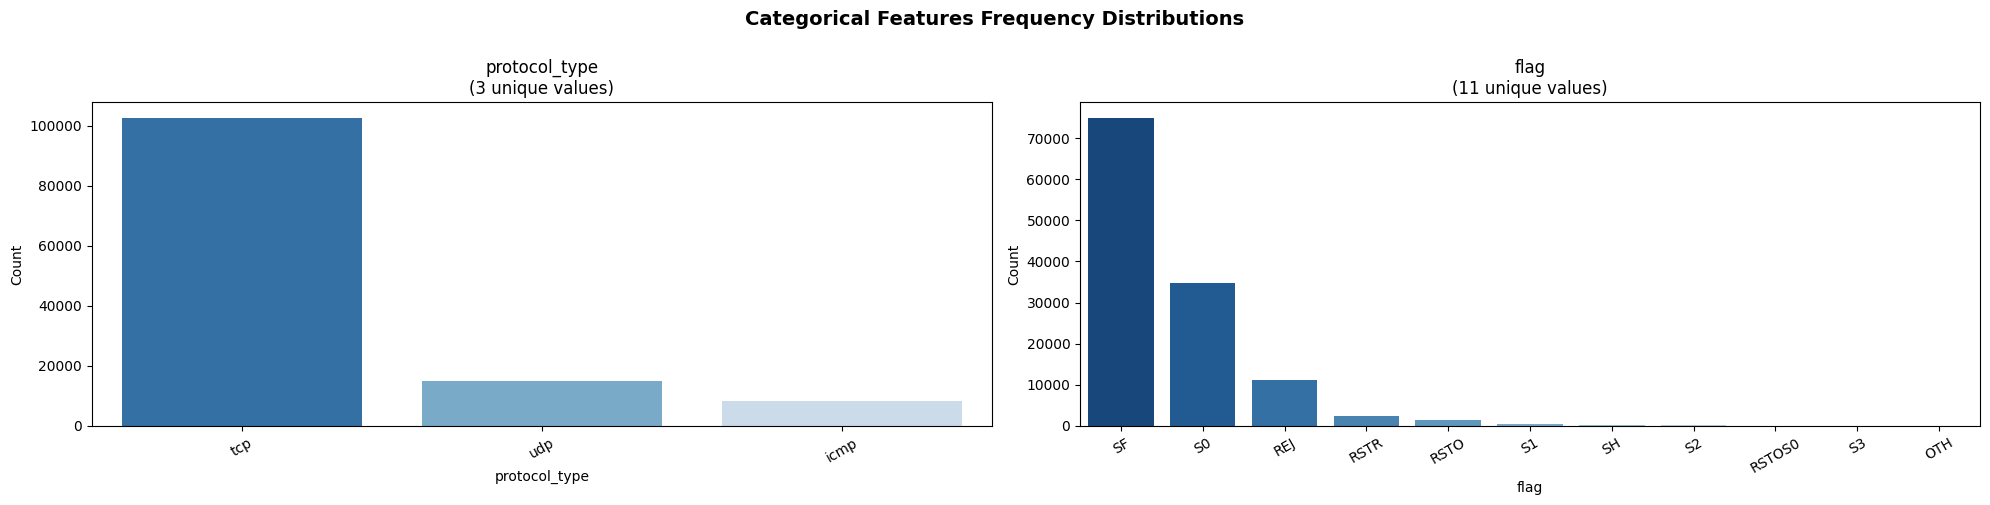

In [32]:
fig, axes=plt.subplots(1,2, figsize=(20,5))
fig.suptitle("Categorical Features Frequency Distributions", fontsize=14, fontweight='bold', y=1.00)

for ax, col in zip(axes, ['protocol_type', 'flag']):
    freq=train_df[col].value_counts()
    # Service has 70 unique values, hence it needs special treatment :3
    if col=='service':
        sns.barplot(x=freq.values, y=freq.index, ax=ax, palette='Blues_r', orient='h')
        ax.set_xlabel('Count (log scale)')
        ax.set_xscale('log')
        ax.tick_params(axis='y', labelsize=6)
    else:
        sns.barplot(x=freq.index, y=freq.values, ax=ax, palette='Blues_r')
        ax.set_xlabel(col)
        ax.set_ylabel('Count')
        ax.tick_params(axis='x', rotation=30)
    
    ax.set_title(f'{col}\n({train_df[col].nunique()} unique values)')

plt.tight_layout()
plt.savefig('../outputs/stage2_cardinality_audit.png', dpi=150, bbox_inches='tight')
plt.show()
    

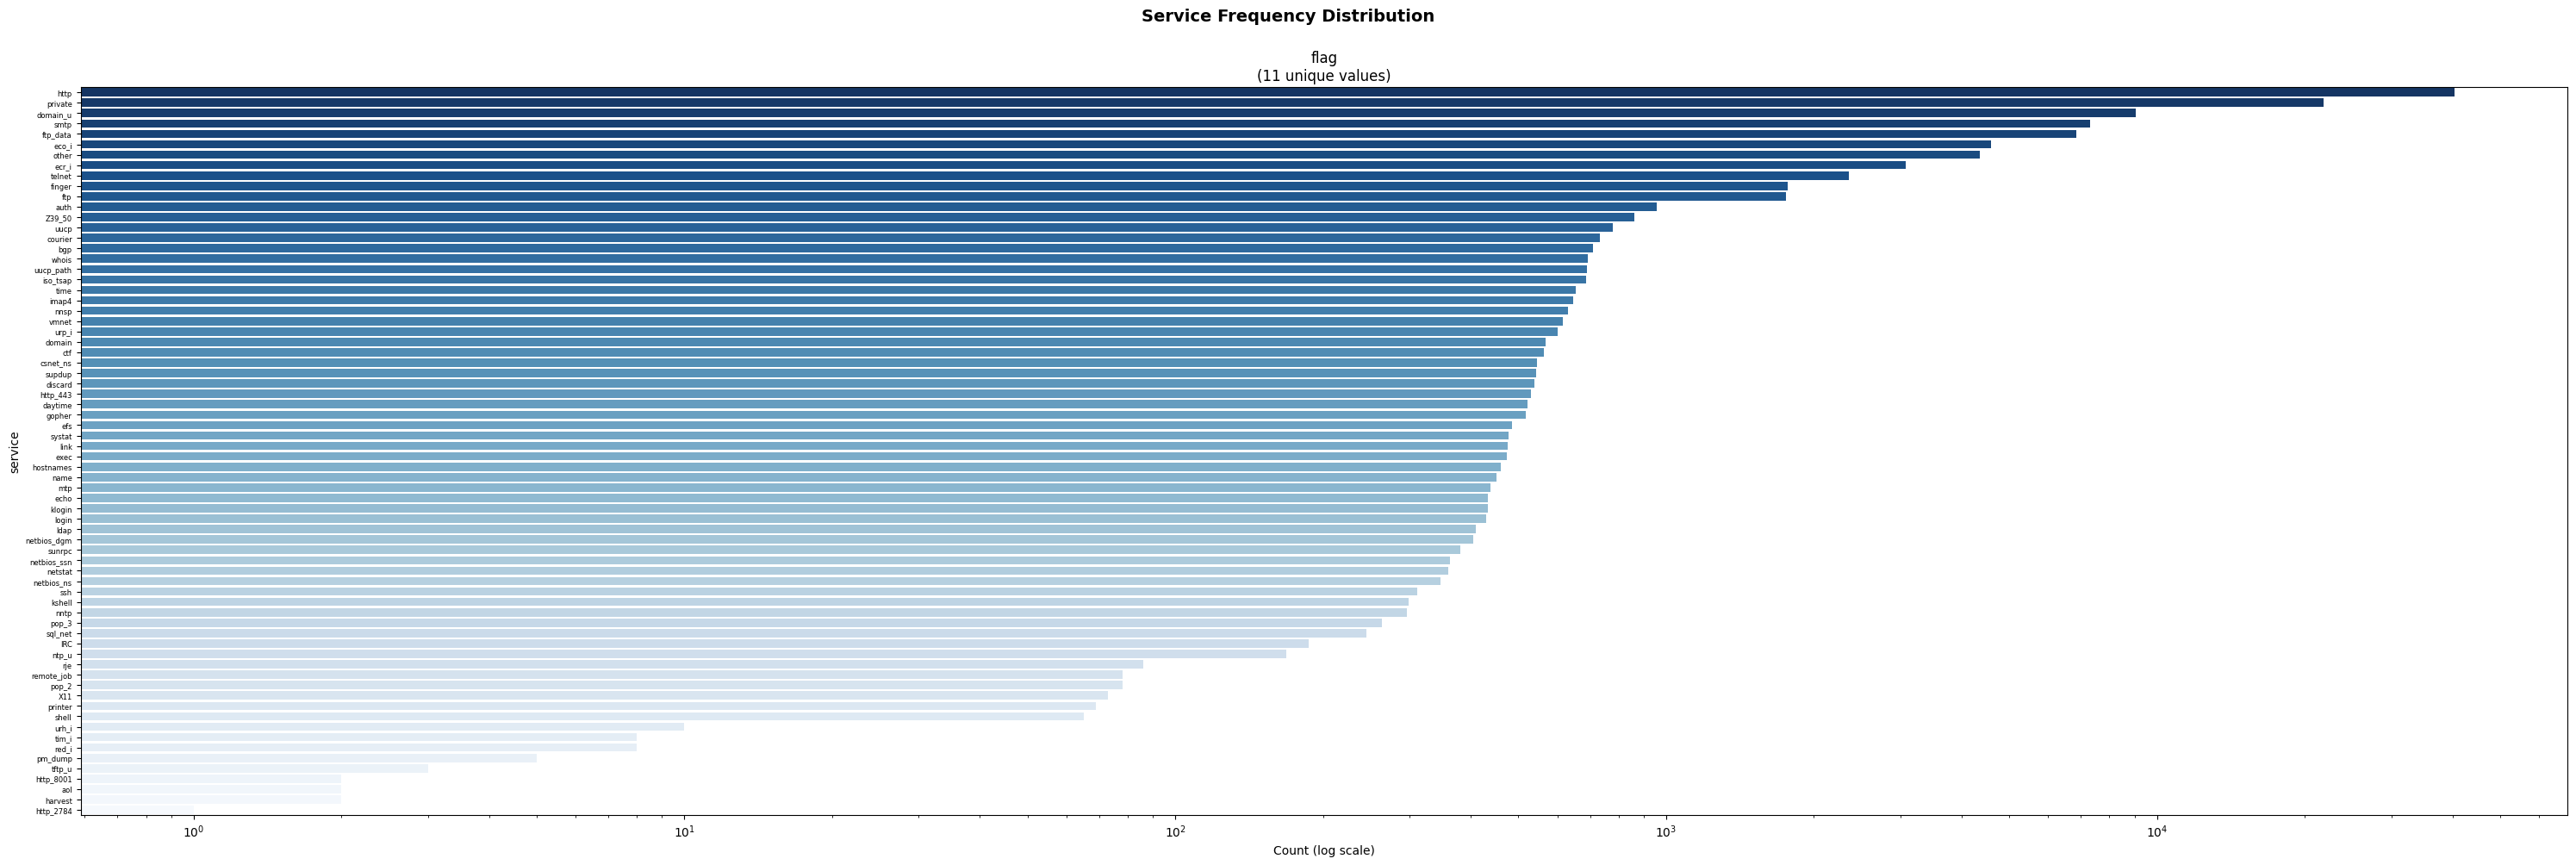

In [40]:
fig, ax=plt.subplots(1,1, figsize=(30,10))
fig.suptitle("Service Frequency Distribution", fontsize=14, fontweight='bold', y=1.00)

freq=train_df['service'].value_counts()
# Service has 70 unique values, hence it needs special treatment :3
sns.barplot(x=freq.values, y=freq.index, ax=ax, palette='Blues_r', orient='h')
ax.set_xlabel('Count (log scale)')
ax.set_xscale('log')
ax.tick_params(axis='y', labelsize=6)

ax.set_title(f'{col}\n({train_df[col].nunique()} unique values)')

plt.tight_layout()
plt.savefig('../outputs/stage2_service_cardinality_audit_.png', dpi=150, bbox_inches='tight')
plt.show()

In [41]:
print("<--- Checking for Zero Variance or Near Zero Variance Columns", f"{"-"*35}>")
variance_report=[]

for col in numeric_cols:
    var=train_df[col].var()
    dominant_val=train_df[col].value_counts().index[0]
    dominant_pct=(train_df[col]==dominant_val).mean()*100
    n_unique=train_df[col].nunique()
    
    variance_report.append({
        'feature': col,
        'variance': round(var, 6),
        'n_unique': n_unique,
        'dominant_value': dominant_val,
        'dominant_pct': round(dominant_pct, 2)
    })

var_df=pd.DataFrame(variance_report).sort_values('dominant_pct', ascending=False)
print(var_df.to_string(index=False))

# Flag features where dominant value covers 99%+ of records
nzv_features=var_df[var_df['dominant_pct'] >= 99.0]['feature'].tolist()
zero_var_features=var_df[var_df['variance'] == 0]['feature'].tolist()

print(f"\n--- Zero variance features: {zero_var_features}")
print(f"--- Near-zero variance features (≥99% dominant): {nzv_features}")

<--- Checking for Zero Variance or Near Zero Variance Columns ----------------------------------->
                    feature     variance  n_unique  dominant_value  dominant_pct
              is_host_login 8.000000e-06         2             0.0        100.00
          num_outbound_cmds 0.000000e+00         1             0.0        100.00
                     urgent 2.060000e-04         4             0.0         99.99
                       land 1.980000e-04         2             0.0         99.98
                 num_shells 4.920000e-04         3             0.0         99.96
               su_attempted 2.039000e-03         3             0.0         99.94
          num_failed_logins 2.047000e-03         6             0.0         99.90
                 root_shell 1.340000e-03         2             0.0         99.87
         num_file_creations 2.341930e-01        35             0.0         99.77
           num_access_files 9.874000e-03        10             0.0         99.71
          

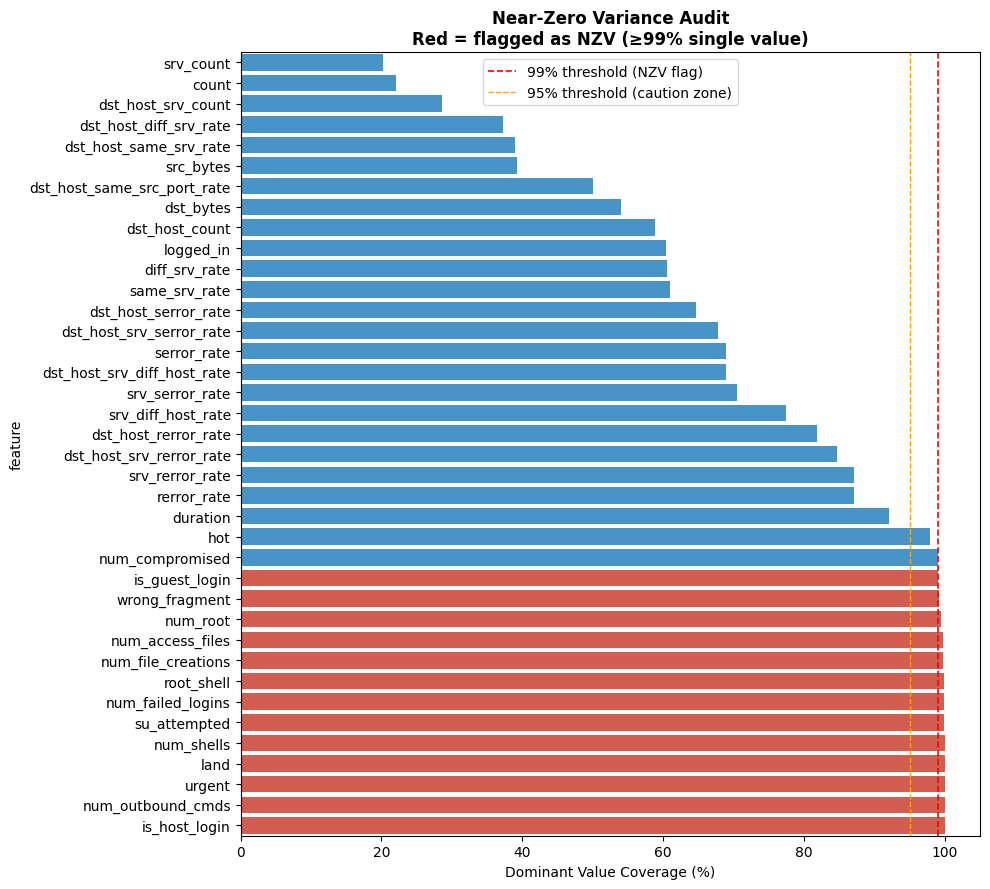

In [43]:
plt.figure(figsize=(10, 9))
var_df_sorted=var_df.sort_values('dominant_pct', ascending=True)

# Color bars: red if dominant_pct >= 99, blue otherwise
colors=['#e74c3c' if v >= 99 else '#3498db' for v in var_df_sorted['dominant_pct']]
sns.barplot(x='dominant_pct', y='feature', data=var_df_sorted, palette=colors, orient='h')

plt.axvline(x=99, color='red', linestyle='--', linewidth=1.2,  label='99% threshold (NZV flag)')
plt.axvline(x=95, color='orange', linestyle='--', linewidth=1.0, label='95% threshold (caution zone)')

plt.xlabel('Dominant Value Coverage (%)')
plt.title('Near-Zero Variance Audit\nRed = flagged as NZV (≥99% single value)', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/stage2_nzv_audit.png', dpi=150, bbox_inches='tight')
plt.show()

In [45]:
all_flagged=list(set(zero_var_features+nzv_features))

for col in all_flagged:
    print(f"\n--- {col} ---:")
    vc=train_df[col].value_counts()
    pct=(vc/len(train_df) * 100).round(3)
    print(pd.DataFrame({'count': vc, 'pct_%': pct}).to_string())


--- root_shell ---:
             count   pct_%
root_shell                
0           125804  99.866
1              169   0.134

--- num_shells ---:
             count   pct_%
num_shells                
0           125926  99.963
1               42   0.033
2                5   0.004

--- urgent ---:
         count   pct_%
urgent                
0       125964  99.993
1            5   0.004
2            3   0.002
3            1   0.001

--- su_attempted ---:
               count   pct_%
su_attempted                
0             125893  99.936
2                 59   0.047
1                 21   0.017

--- num_file_creations ---:
                     count   pct_%
num_file_creations                
0                   125686  99.772
1                      151   0.120
2                       41   0.033
4                       13   0.010
8                        5   0.004
15                       5   0.004
5                        5   0.004
17                       5   0.004
3            

In [48]:
print("""
STAGE 2 FINDINGS SUMMARY
─────────────────────────────────────────
Nulls found:                NO
Sentinel negatives found:   NO
Duplicates (train):         16 rows (0.01%) — flag for soft drop
Duplicates (test):          57 rows (0.25%) — flag for soft drop

Cardinality notes:
  protocol_type : 2 values cover 90% — low cardinality, safe for OHE
  flag          : 3 values (SF, S0, REJ) cover 96% — moderate, OHE viable
                  S0 at 27.67% is anomalously high — domain flag
  service       : 26 values cover 90%, bottom 44 are sparse tail
                  Singleton/near-singleton values identified
                  Requires frequency encoding or rare-grouping strategy

Zero-variance features:     [num_outbound_cmds] — KEEP, domain justification
NZV features (≥99%):        is_host_login, urgent, land, num_shells,
                            su_attempted, num_failed_logins, root_shell,
                            num_file_creations, num_access_files,
                            num_root, wrong_fragment, is_guest_login
                            — ALL KEPT, treated as behavioral indicator cluster

Special flags:
  num_root: spike-sparse distribution, extreme outliers (up to 7468)
            requires RobustScaler or log-floor transform in Stage 4
  flag=S0:  27.67% presence suggests attack contamination in training data
─────────────────────────────────────────
""")


STAGE 2 FINDINGS SUMMARY
─────────────────────────────────────────
Nulls found:                NO
Sentinel negatives found:   NO
Duplicates (train):         16 rows (0.01%) — flag for soft drop
Duplicates (test):          57 rows (0.25%) — flag for soft drop

Cardinality notes:
  protocol_type : 2 values cover 90% — low cardinality, safe for OHE
  flag          : 3 values (SF, S0, REJ) cover 96% — moderate, OHE viable
                  S0 at 27.67% is anomalously high — domain flag
  service       : 26 values cover 90%, bottom 44 are sparse tail
                  Singleton/near-singleton values identified
                  Requires frequency encoding or rare-grouping strategy

Zero-variance features:     [num_outbound_cmds] — KEEP, domain justification
NZV features (≥99%):        is_host_login, urgent, land, num_shells,
                            su_attempted, num_failed_logins, root_shell,
                            num_file_creations, num_access_files,
                            

# Stage 3-A
> Part-A of a 4 Part Exploratory Data Analsysis

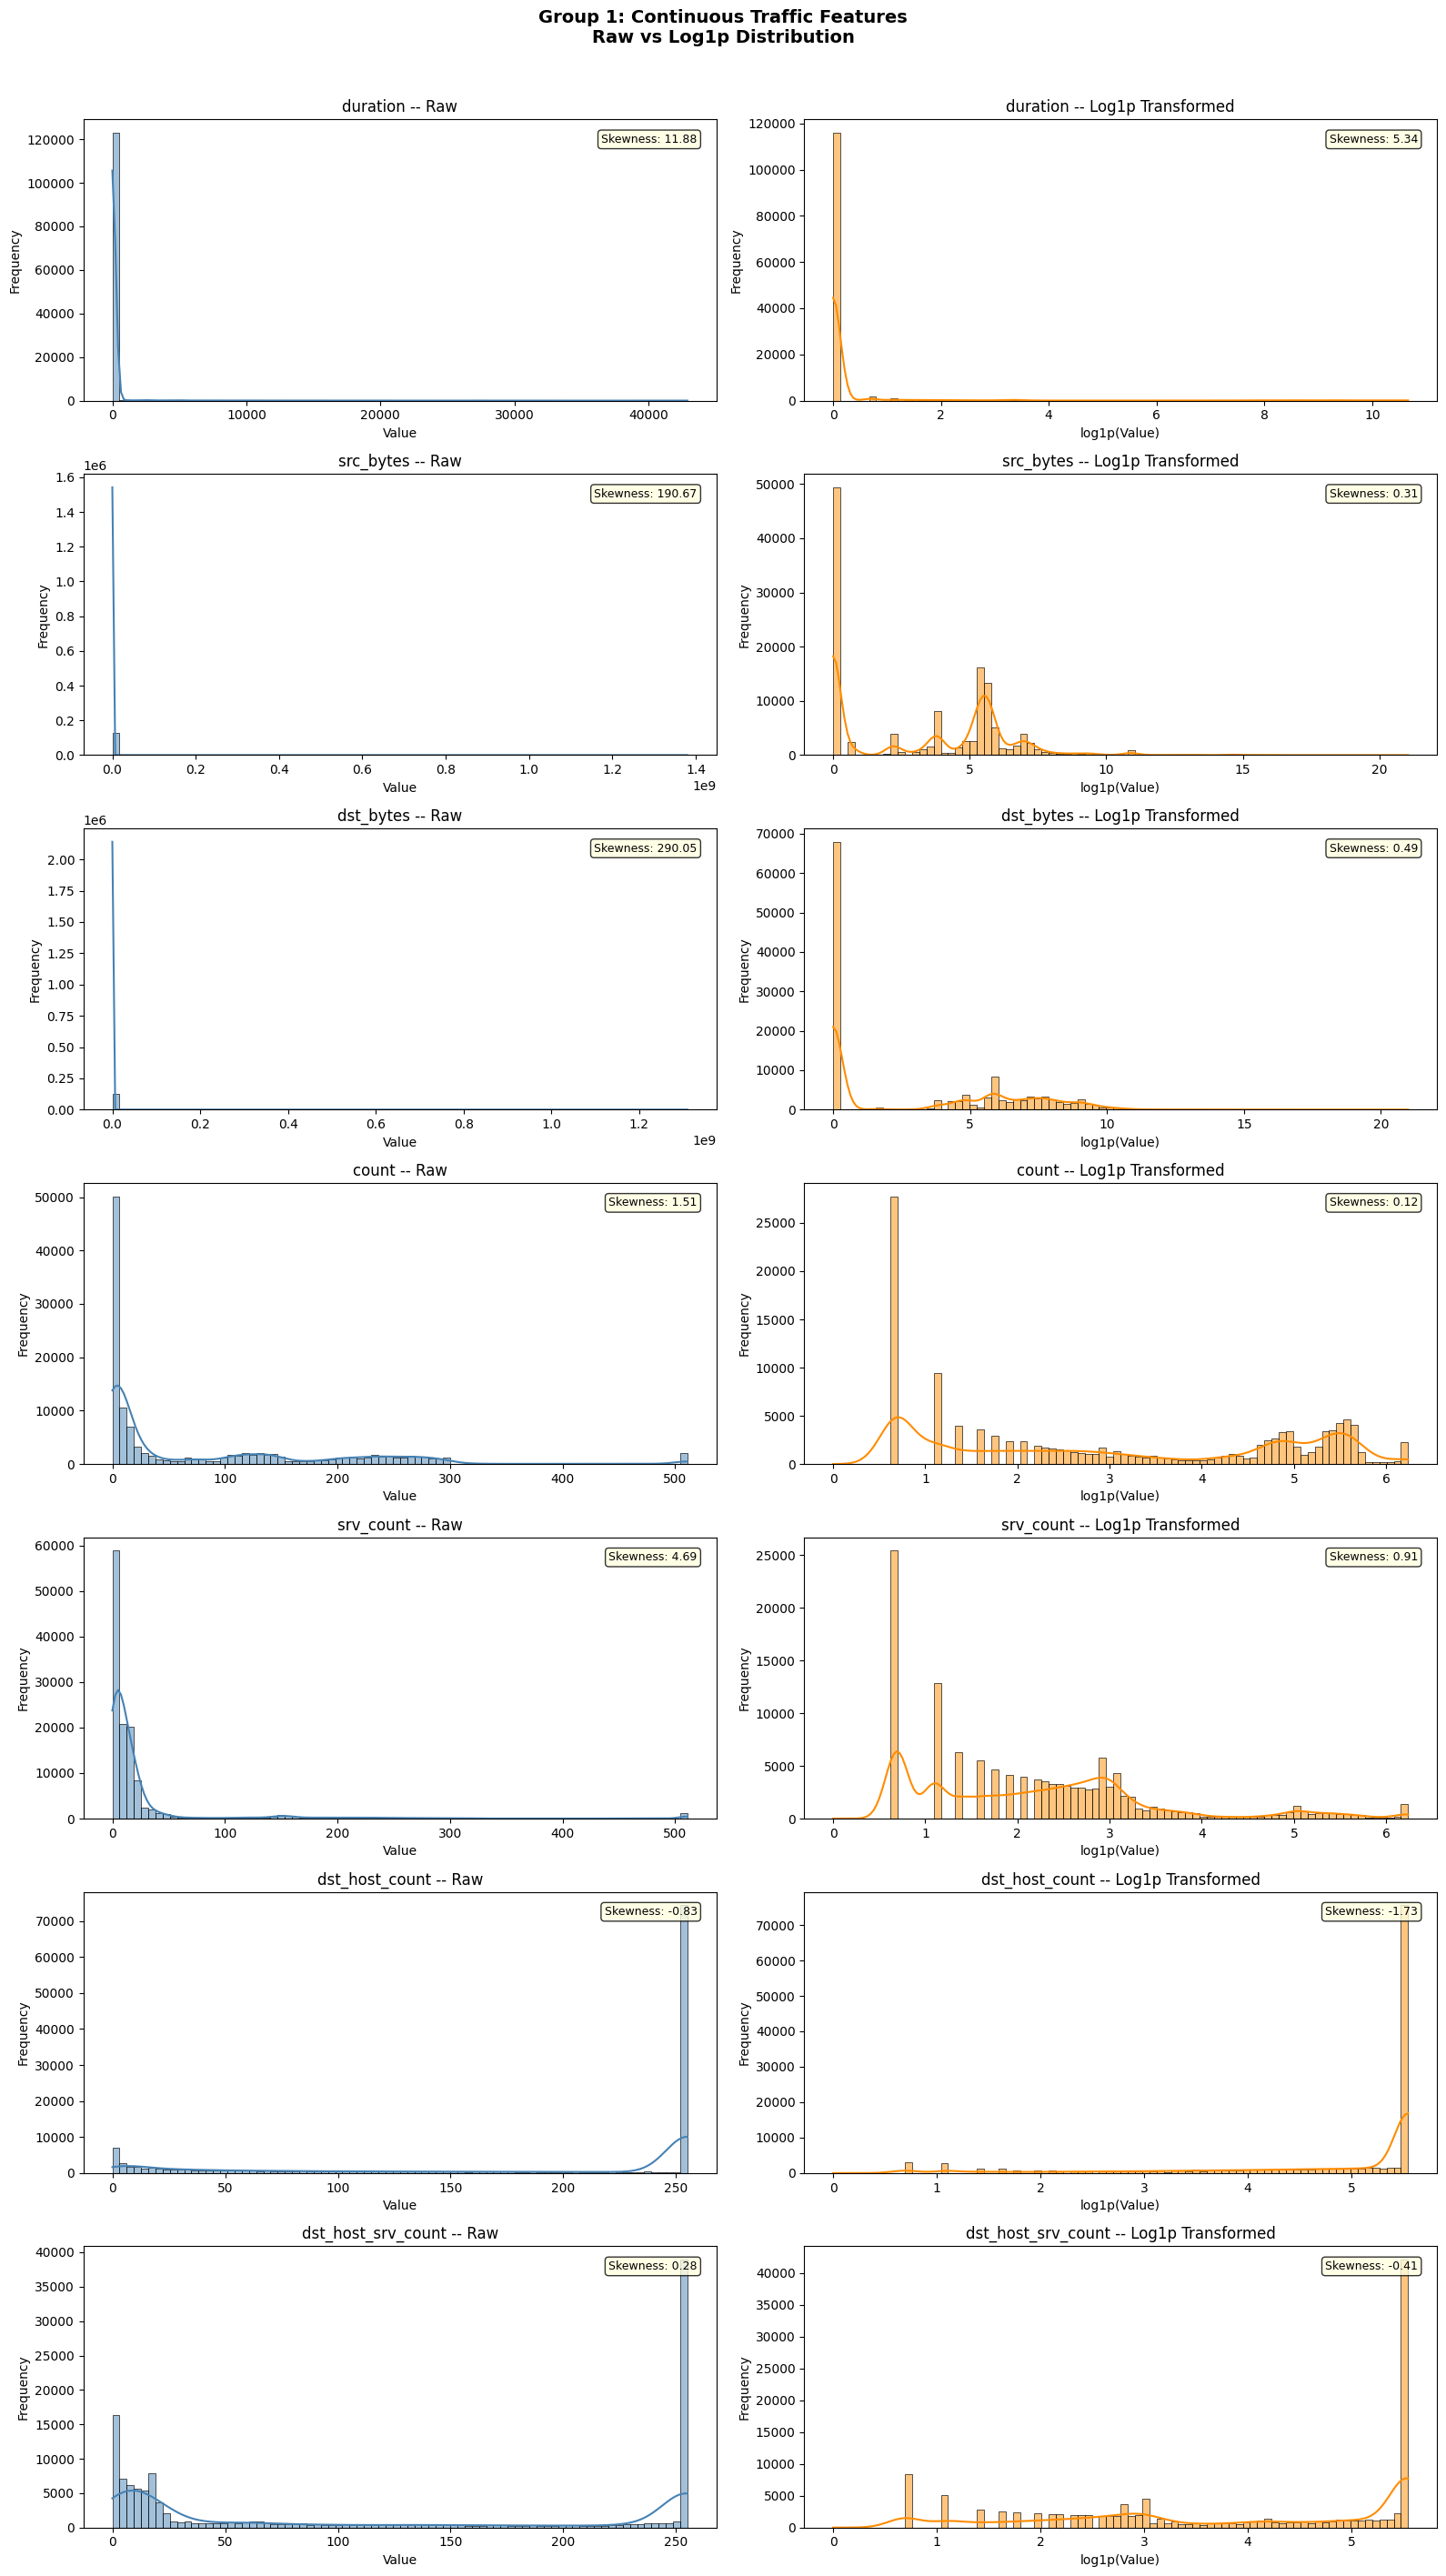

In [49]:
heavy_tail_candidates=[
    'duration', 'src_bytes', 'dst_bytes',
    'count', 'srv_count',
    'dst_host_count', 'dst_host_srv_count'
]

fig, axes=plt.subplots(len(heavy_tail_candidates), 2, figsize=(16, 4 * len(heavy_tail_candidates)))
fig.suptitle('Group 1: Continuous Traffic Features\nRaw vs Log1p Distribution', fontsize=14, fontweight='bold', y=1.01)
for i, col in enumerate(heavy_tail_candidates):
    raw_data=train_df[col]
    log_data=np.log1p(train_df[col]) #log(1+x), handles zeroes

    sns.histplot(raw_data, bins=80, ax=axes[i, 0], color='steelblue', kde=True)
    axes[i, 0].set_title(f'{col} -- Raw')
    axes[i, 0].set_xlabel('Value')
    axes[i, 0].set_ylabel('Frequency')

    #Annotate skewness directly on the plot
    skew_val=raw_data.skew()
    axes[i, 0].annotate(f'Skewness: {skew_val:.2f}',xy=(0.97, 0.95), xycoords='axes fraction',ha='right', va='top',
                        fontsize=9,bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

    # Log1p distribution
    sns.histplot(log_data, bins=80, ax=axes[i, 1], color='darkorange', kde=True)
    axes[i, 1].set_title(f'{col} -- Log1p Transformed')
    axes[i, 1].set_xlabel('log1p(Value)')
    axes[i, 1].set_ylabel('Frequency')

    log_skew = log_data.skew()
    axes[i, 1].annotate(f'Skewness: {log_skew:.2f}',xy=(0.97, 0.95), xycoords='axes fraction',ha='right', va='top',
                         fontsize=9,bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('../outputs/stage3a_group1_heavy_tail.png', dpi=150, bbox_inches='tight')
plt.show()


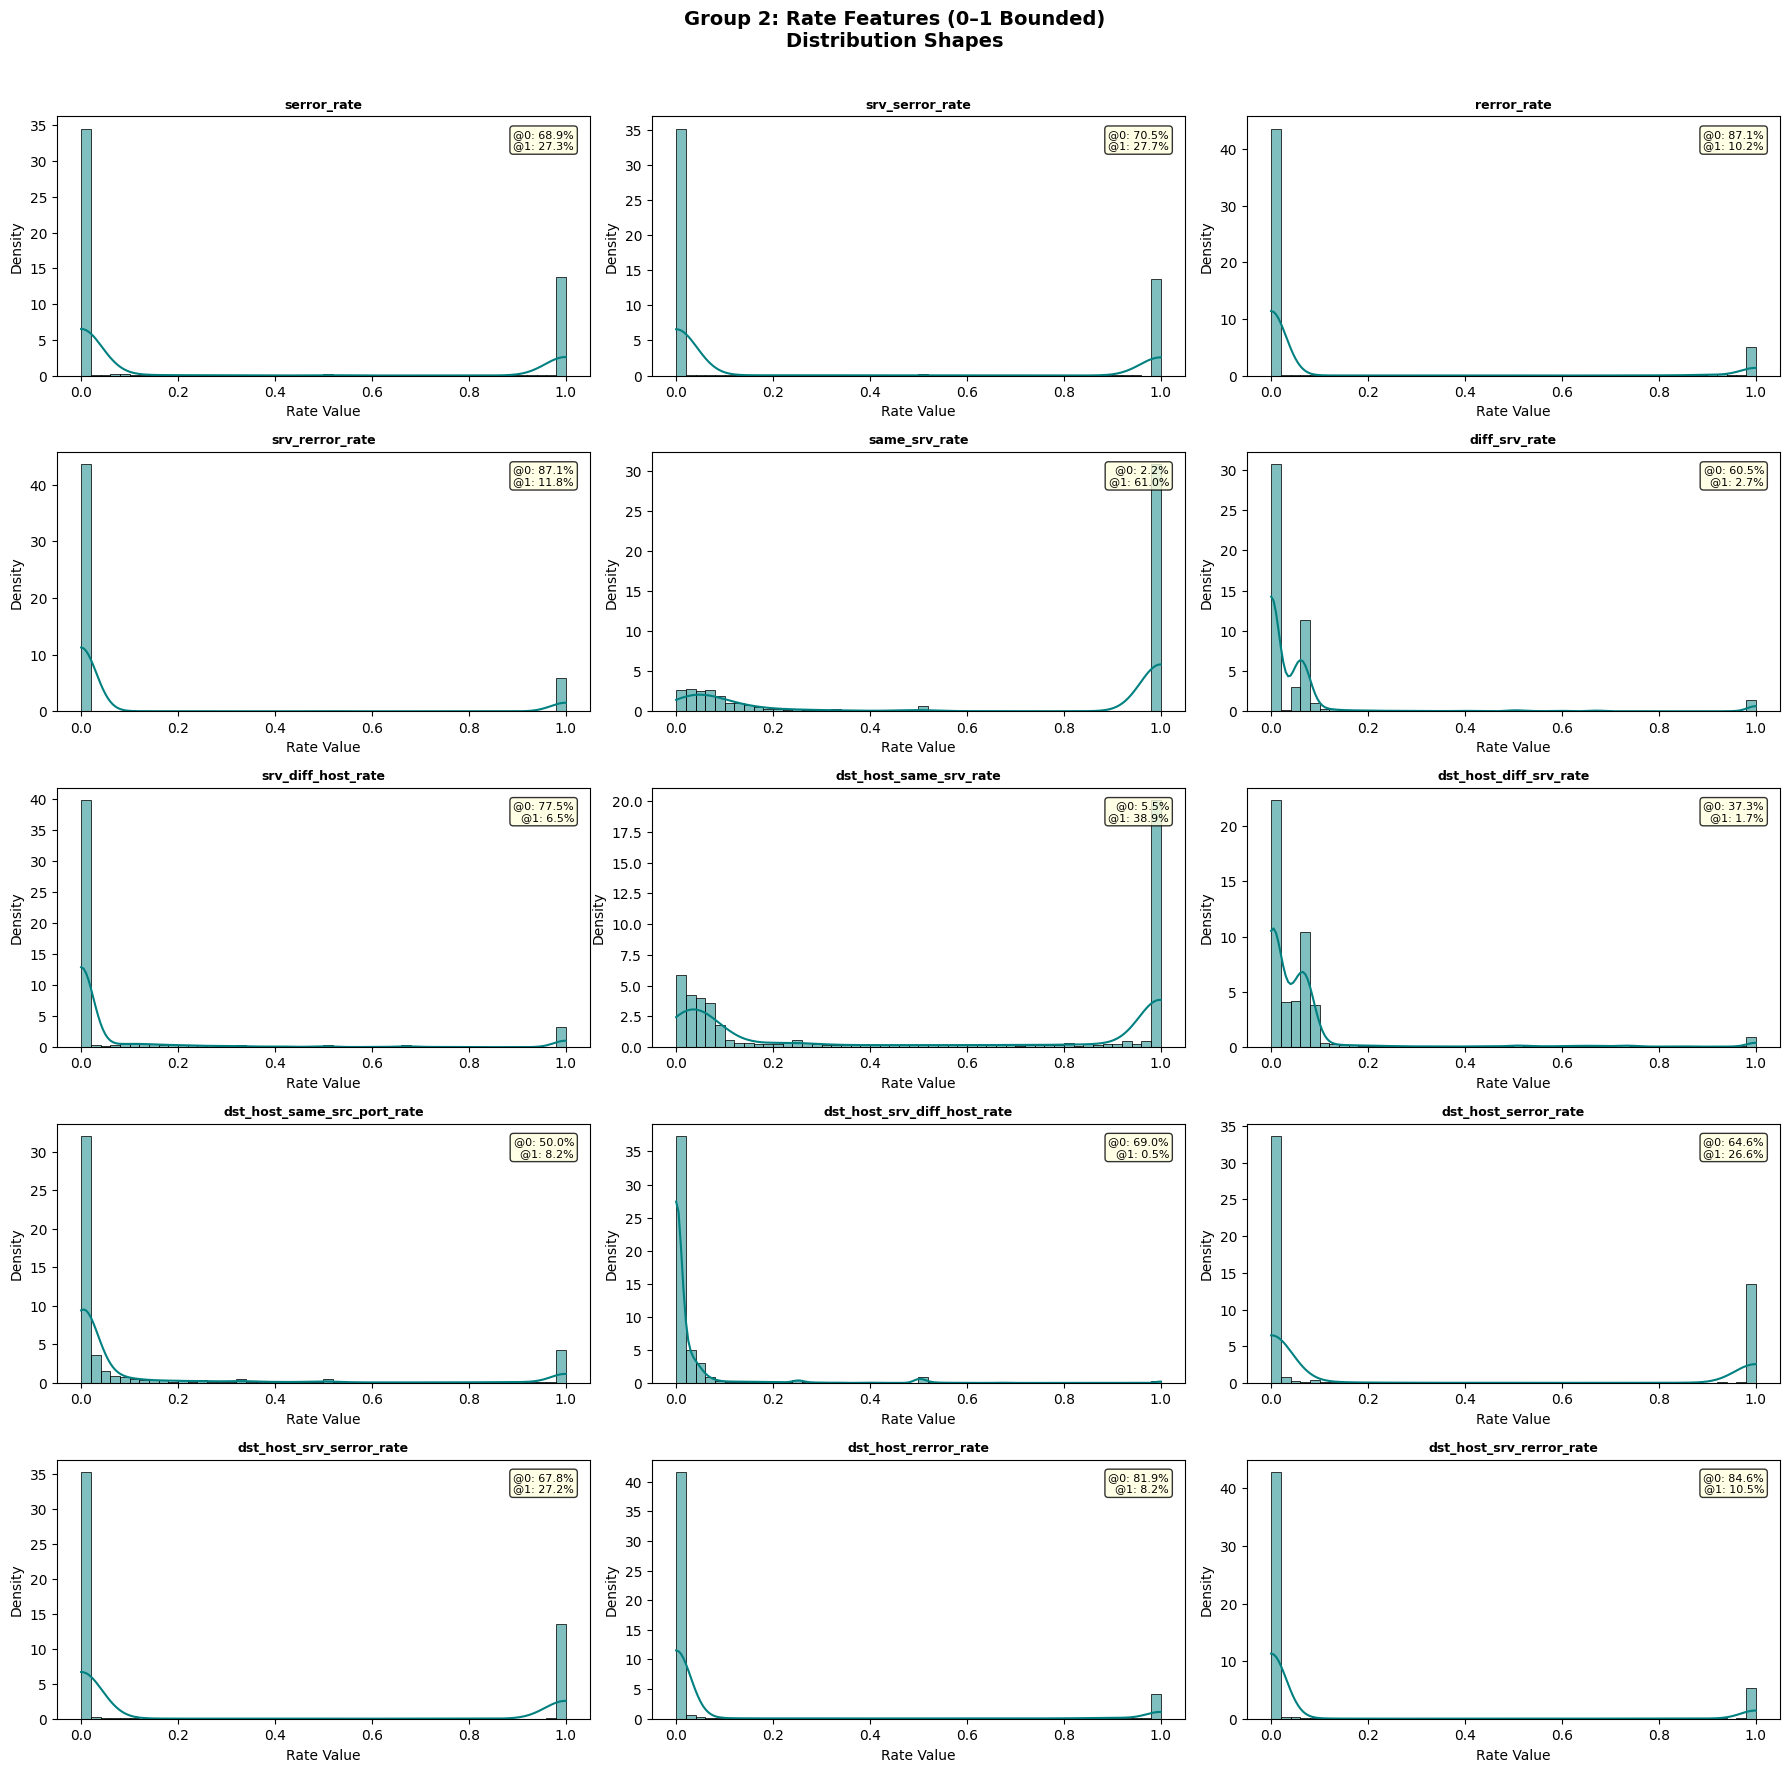

In [51]:
rate_features = [
    'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate',
    'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate'
]

n=len(rate_features)
ncols=3
nrows=(n+ncols-1)//ncols

fig, axes=plt.subplots(nrows, ncols, figsize=(18, nrows * 3.5))
fig.suptitle('Group 2: Rate Features (0–1 Bounded)\nDistribution Shapes', fontsize=14, fontweight='bold', y=1.01)

axes_flat=axes.flatten()

for i, col in enumerate(rate_features):
    ax=axes_flat[i]
    
    # For 0-1 bounded features, use KDE + rug for shape
    # bins=50 gives enough resolution to see the 0/1 spike structure
    sns.histplot(train_df[col], bins=50, ax=ax, color='teal', kde=True, stat='density')
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.set_xlabel('Rate Value')
    ax.set_ylabel('Density')
    ax.set_xlim(-0.05, 1.05)
    
    # Annotate the fraction of records at exactly 0 and exactly 1
    # This tells us how bimodal the feature is
    pct_zero=(train_df[col]==0).mean()*100
    pct_one=(train_df[col]==1).mean()*100
    ax.annotate(f'@0: {pct_zero:.1f}%\n@1: {pct_one:.1f}%', xy=(0.97, 0.95), xycoords='axes fraction',
                ha='right', va='top', fontsize=8, bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

# Turn off unused subplots
for j in range(i+1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/stage3a_group2_rate_features.png', dpi=150, bbox_inches='tight')
plt.show()

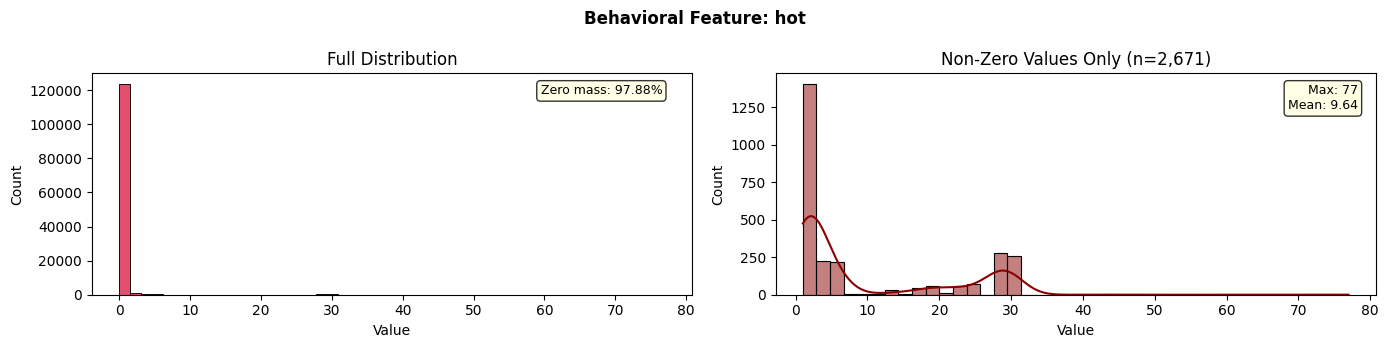

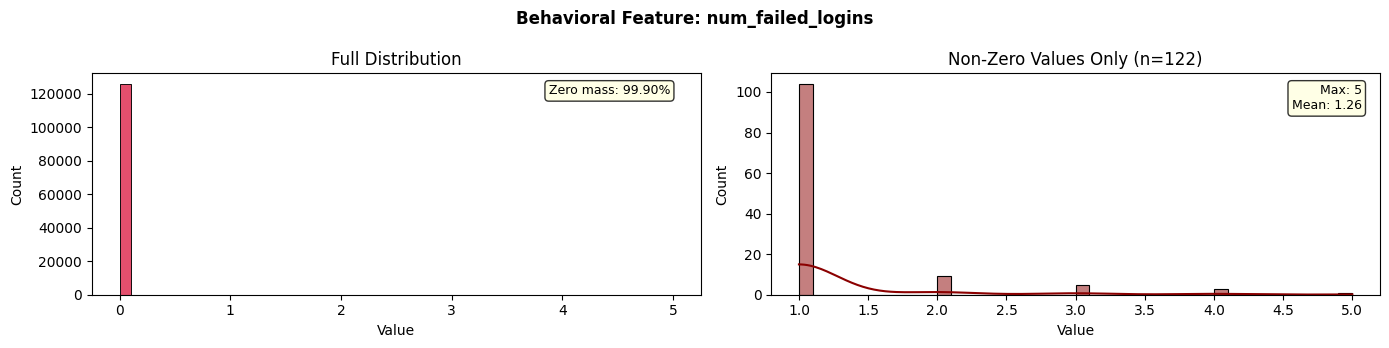

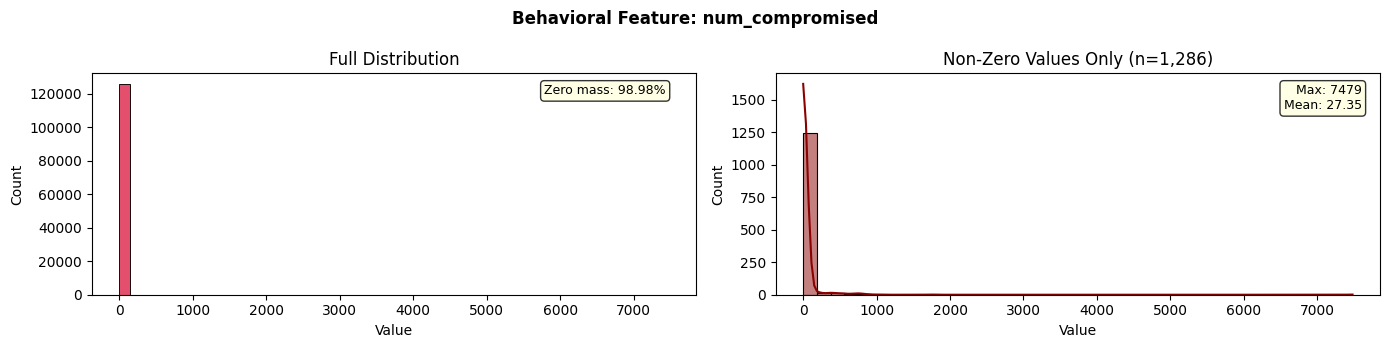

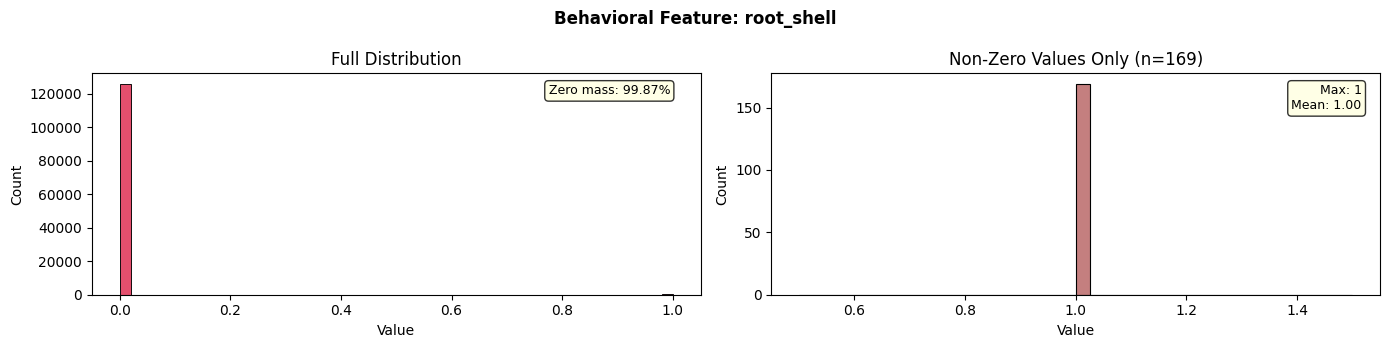

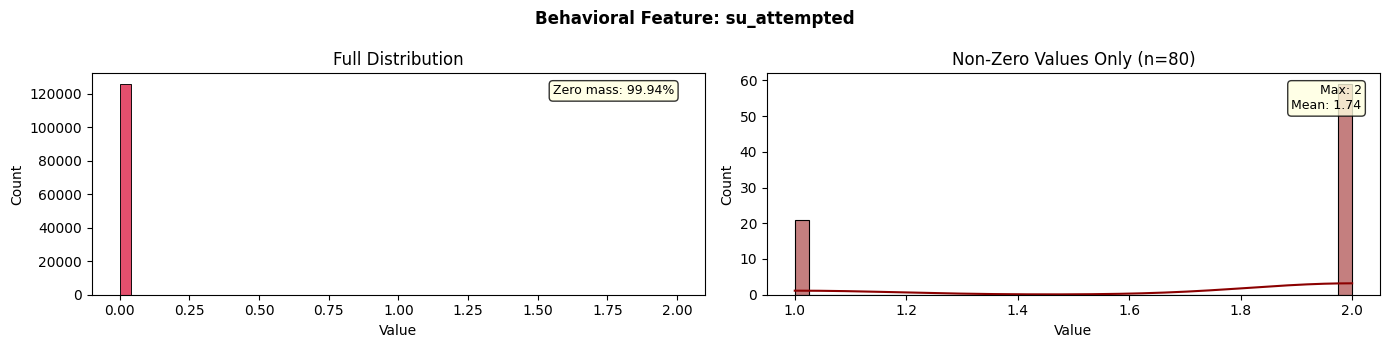

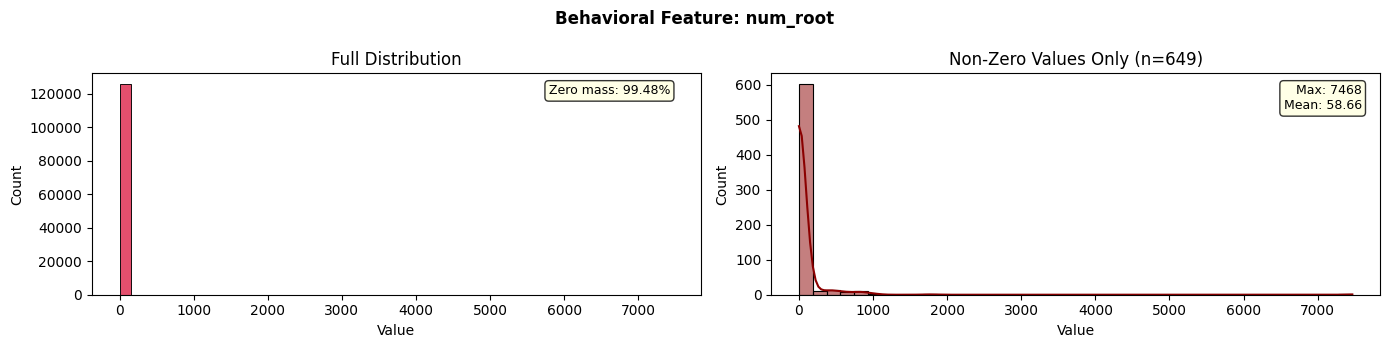

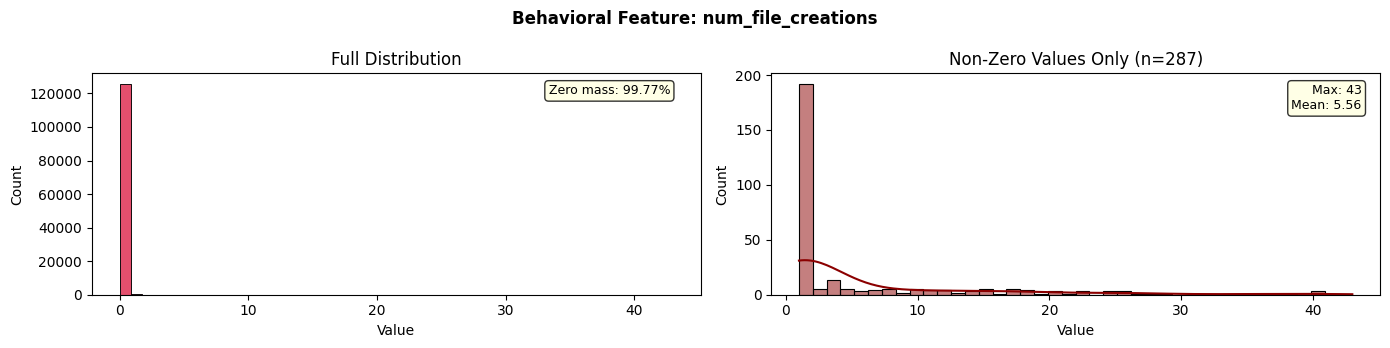

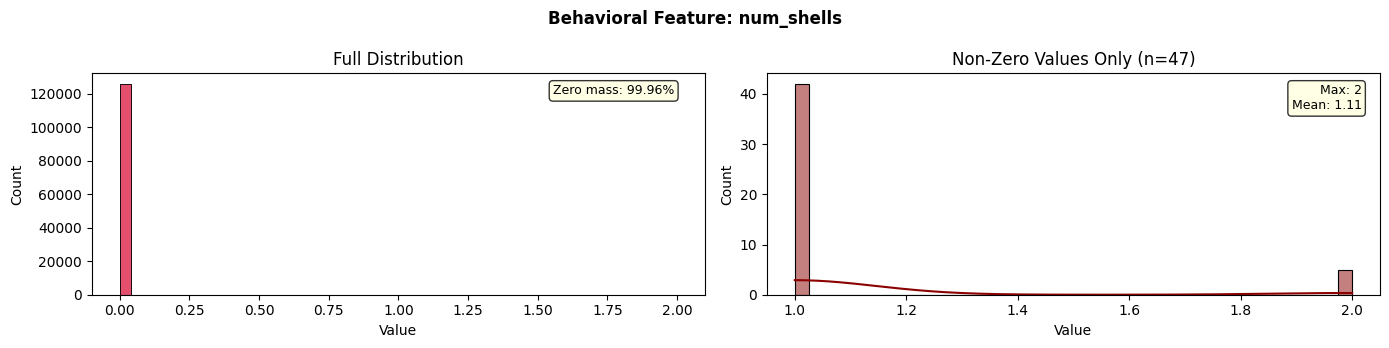

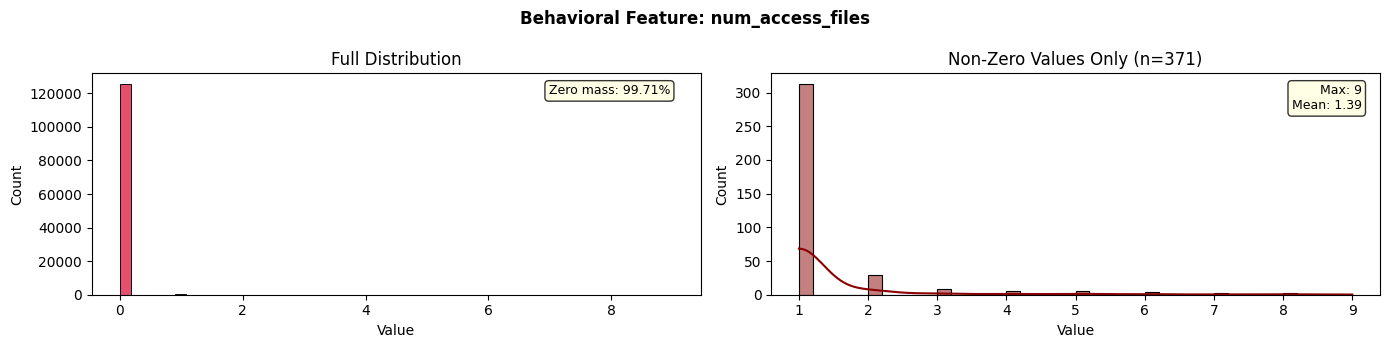

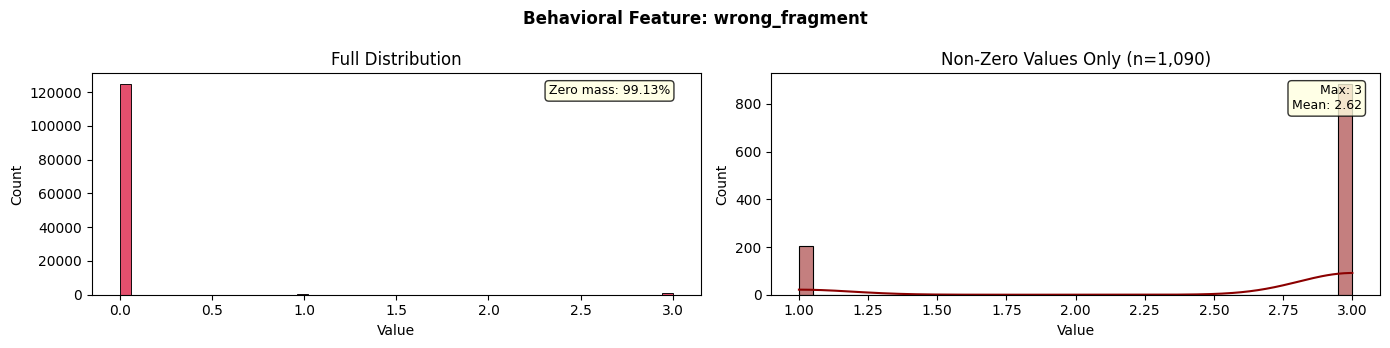

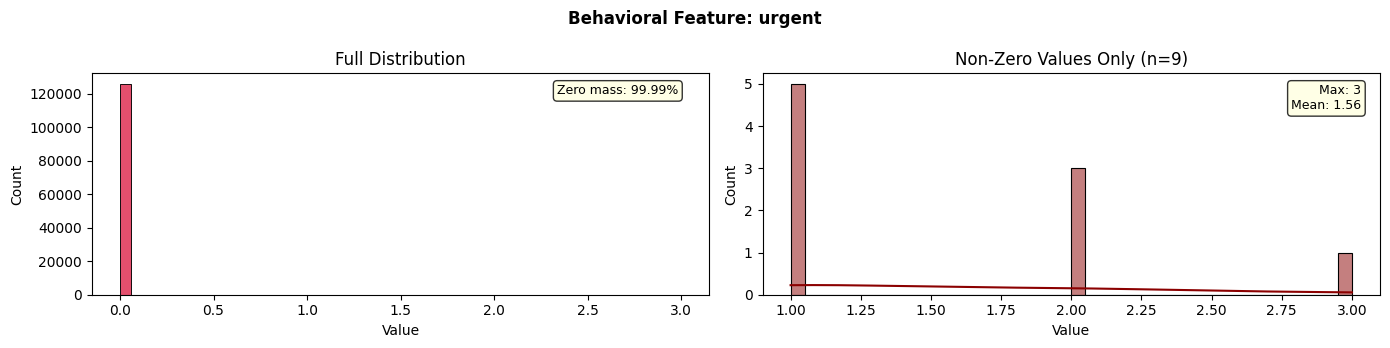

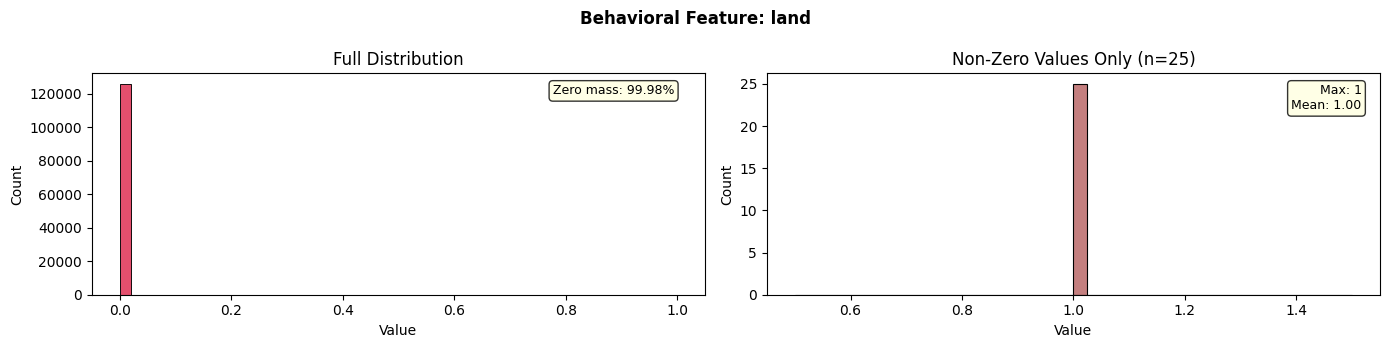

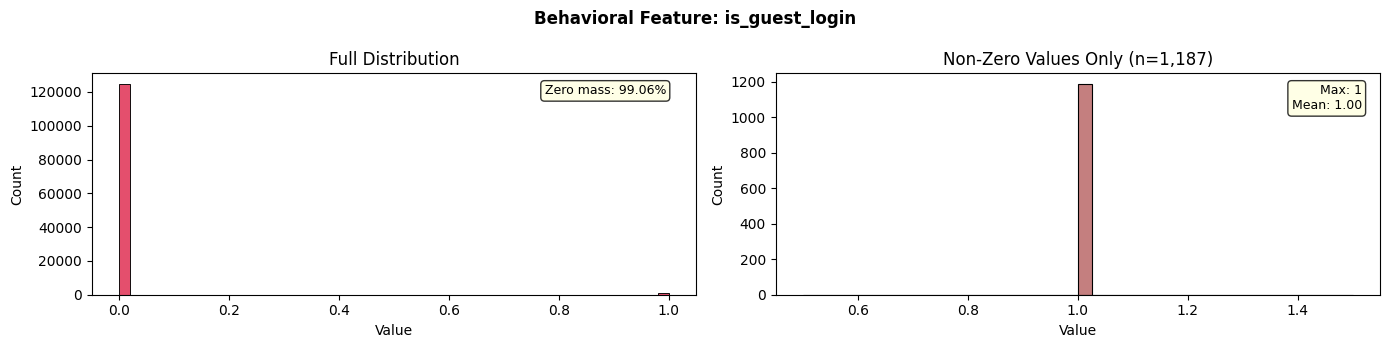

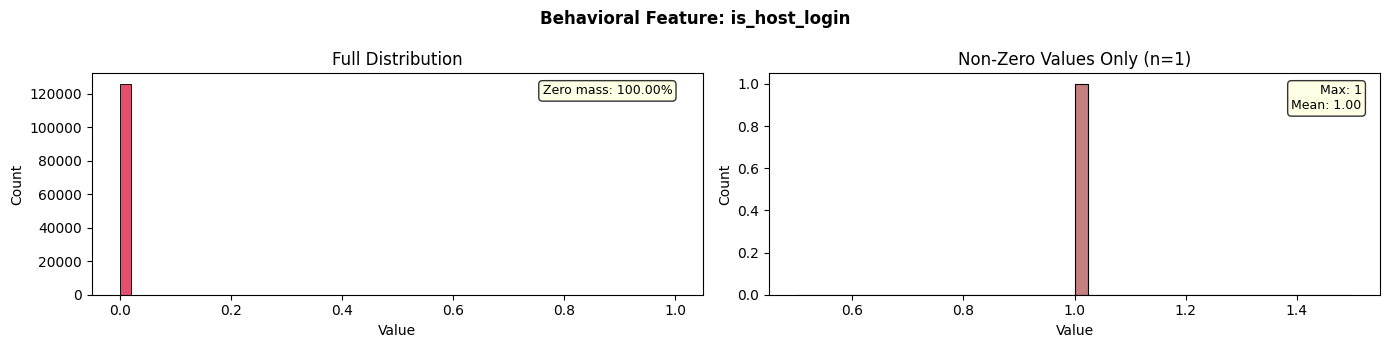

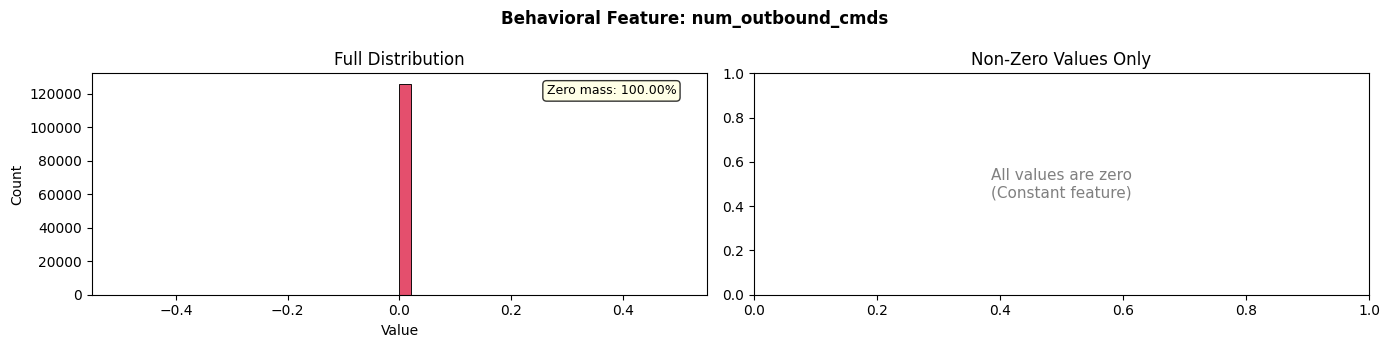

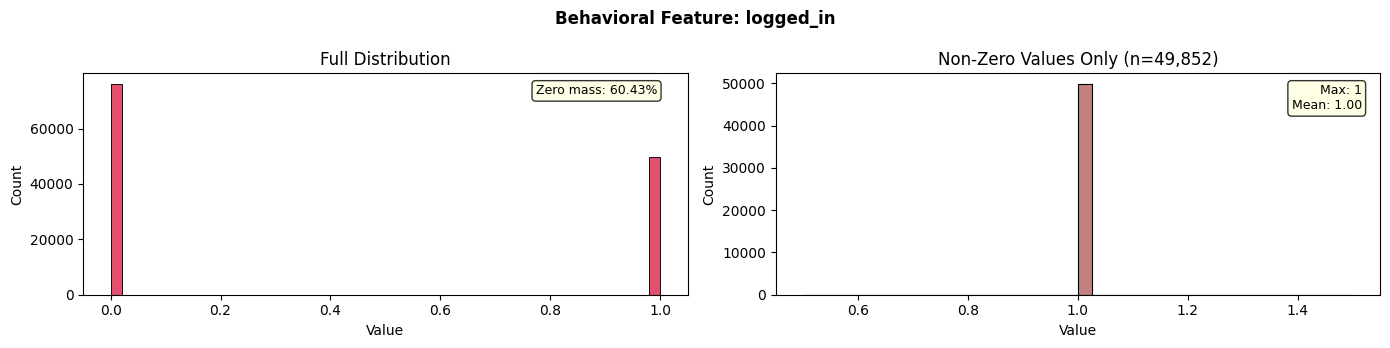

In [54]:
behavioral_features=[
    'hot', 'num_failed_logins', 'num_compromised', 'root_shell',
    'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
    'num_access_files', 'wrong_fragment', 'urgent', 'land',
    'is_guest_login', 'is_host_login', 'num_outbound_cmds', 'logged_in'
]

for col in behavioral_features:
    fig, axes=plt.subplots(1, 2, figsize=(14, 3.5))
    fig.suptitle(f'Behavioral Feature: {col}', fontweight='bold', fontsize=12)

    # Left panel: full distribution — confirms the zero dominance
    sns.histplot(train_df[col], bins=50, ax=axes[0], color='crimson', kde=False)
    axes[0].set_title('Full Distribution')
    axes[0].set_xlabel('Value')
    axes[0].set_ylabel('Count')

    pct_zero=(train_df[col]==0).mean()*100
    axes[0].annotate(f'Zero mass: {pct_zero:.2f}%', xy=(0.95, 0.95), xycoords='axes fraction',
                     ha='right', va='top', fontsize=9, bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

    # Right panel: non-zero values only — reveals tail structure
    # values span a huge range (1 to 7468) that a full plot hides
    nonzero=train_df[col][train_df[col] > 0]

    if len(nonzero)>0:
        sns.histplot(nonzero, bins=40, ax=axes[1], color='darkred', kde=True)
        axes[1].set_title(f'Non-Zero Values Only (n={len(nonzero):,})')
        axes[1].set_xlabel('Value')
        axes[1].set_ylabel('Count')

        # Annotate max value so we know the tail extent
        axes[1].annotate(f'Max: {nonzero.max()}\nMean: {nonzero.mean():.2f}', xy=(0.97, 0.95), xycoords='axes fraction', 
                         ha='right', va='top', fontsize=9, bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))
    else:
        axes[1].text(0.5, 0.5, 'All values are zero\n(Constant feature)', ha='center', va='center', transform=axes[1].transAxes, fontsize=11, color='gray')
        axes[1].set_title('Non-Zero Values Only')

    plt.tight_layout()
    plt.savefig(f'../outputs/stage3a_behavioral_{col}.png', dpi=150, bbox_inches='tight')
    plt.show()

In [55]:
print("""STAGE 3A UNIVARIATE FINDINGS — FINALIZED
─────────────────────────────────────────────────────
CONFIRMED LOG1P TRANSFORM:
  src_bytes    (190.67 → 0.31)   — strongest case
  dst_bytes    (290.05 → 0.49)   — strongest case
  duration     (11.88  → 5.34)   — still skewed, multimodal flag
  srv_count    (4.69   → 0.91)   — clean improvement
  count        (1.51   → 0.12)   — bimodal post-transform, flag for 3D

ZERO-INFLATED LOG1P (log on non-zeros, preserve zero mass):
  num_compromised  (max 7497)
  num_root         (max 7468)
  hot              (max 77)
  num_file_creations (max 43)
  num_access_files   (max 9)

ROBUSTSCALER ONLY (ceiling-effect, log worsens):
  dst_host_count      (spikes at 255)
  dst_host_srv_count  (spikes at 255)

PASS-THROUGH AS-IS (binary flags, no scaling):
  root_shell, land, is_guest_login, is_host_login
  su_attempted, wrong_fragment, urgent, num_shells
  logged_in (reclassified from NZV group to binary flag)

CONSTANT — RETAIN, NO TRANSFORM:
  num_outbound_cmds

RATE FEATURES — BIMODALITY CONFIRMED:
  Strongly bimodal (>85% at 0/1): serror group, rerror group
  Inverted spike at 1.0: same_srv_rate, dst_host_same_srv_rate
  Sparse continuous: diff_srv_rate subgroup

DOMAIN FLAGS FOR STAGE 3D:
  count        — bimodal post-log suggests DoS burst population
  same_srv_rate — inverts relative to all other rate features (DoS signature)
  duration     — persistent multimodality even after transform
─────────────────────────────────────────────────────""")

STAGE 3A UNIVARIATE FINDINGS — FINALIZED
─────────────────────────────────────────────────────
CONFIRMED LOG1P TRANSFORM:
  src_bytes    (190.67 → 0.31)   — strongest case
  dst_bytes    (290.05 → 0.49)   — strongest case
  duration     (11.88  → 5.34)   — still skewed, multimodal flag
  srv_count    (4.69   → 0.91)   — clean improvement
  count        (1.51   → 0.12)   — bimodal post-transform, flag for 3D

ZERO-INFLATED LOG1P (log on non-zeros, preserve zero mass):
  num_compromised  (max 7497)
  num_root         (max 7468)
  hot              (max 77)
  num_file_creations (max 43)
  num_access_files   (max 9)

ROBUSTSCALER ONLY (ceiling-effect, log worsens):
  dst_host_count      (spikes at 255)
  dst_host_srv_count  (spikes at 255)

PASS-THROUGH AS-IS (binary flags, no scaling):
  root_shell, land, is_guest_login, is_host_login
  su_attempted, wrong_fragment, urgent, num_shells
  logged_in (reclassified from NZV group to binary flag)

CONSTANT — RETAIN, NO TRANSFORM:
  num_outbound_

# Stage 3B
> Bivariate and Multivariate Analysis

Dissimilarity matrix validated. Shape: (38, 38)
NaN count: 0
Max asymmetry: 0.0


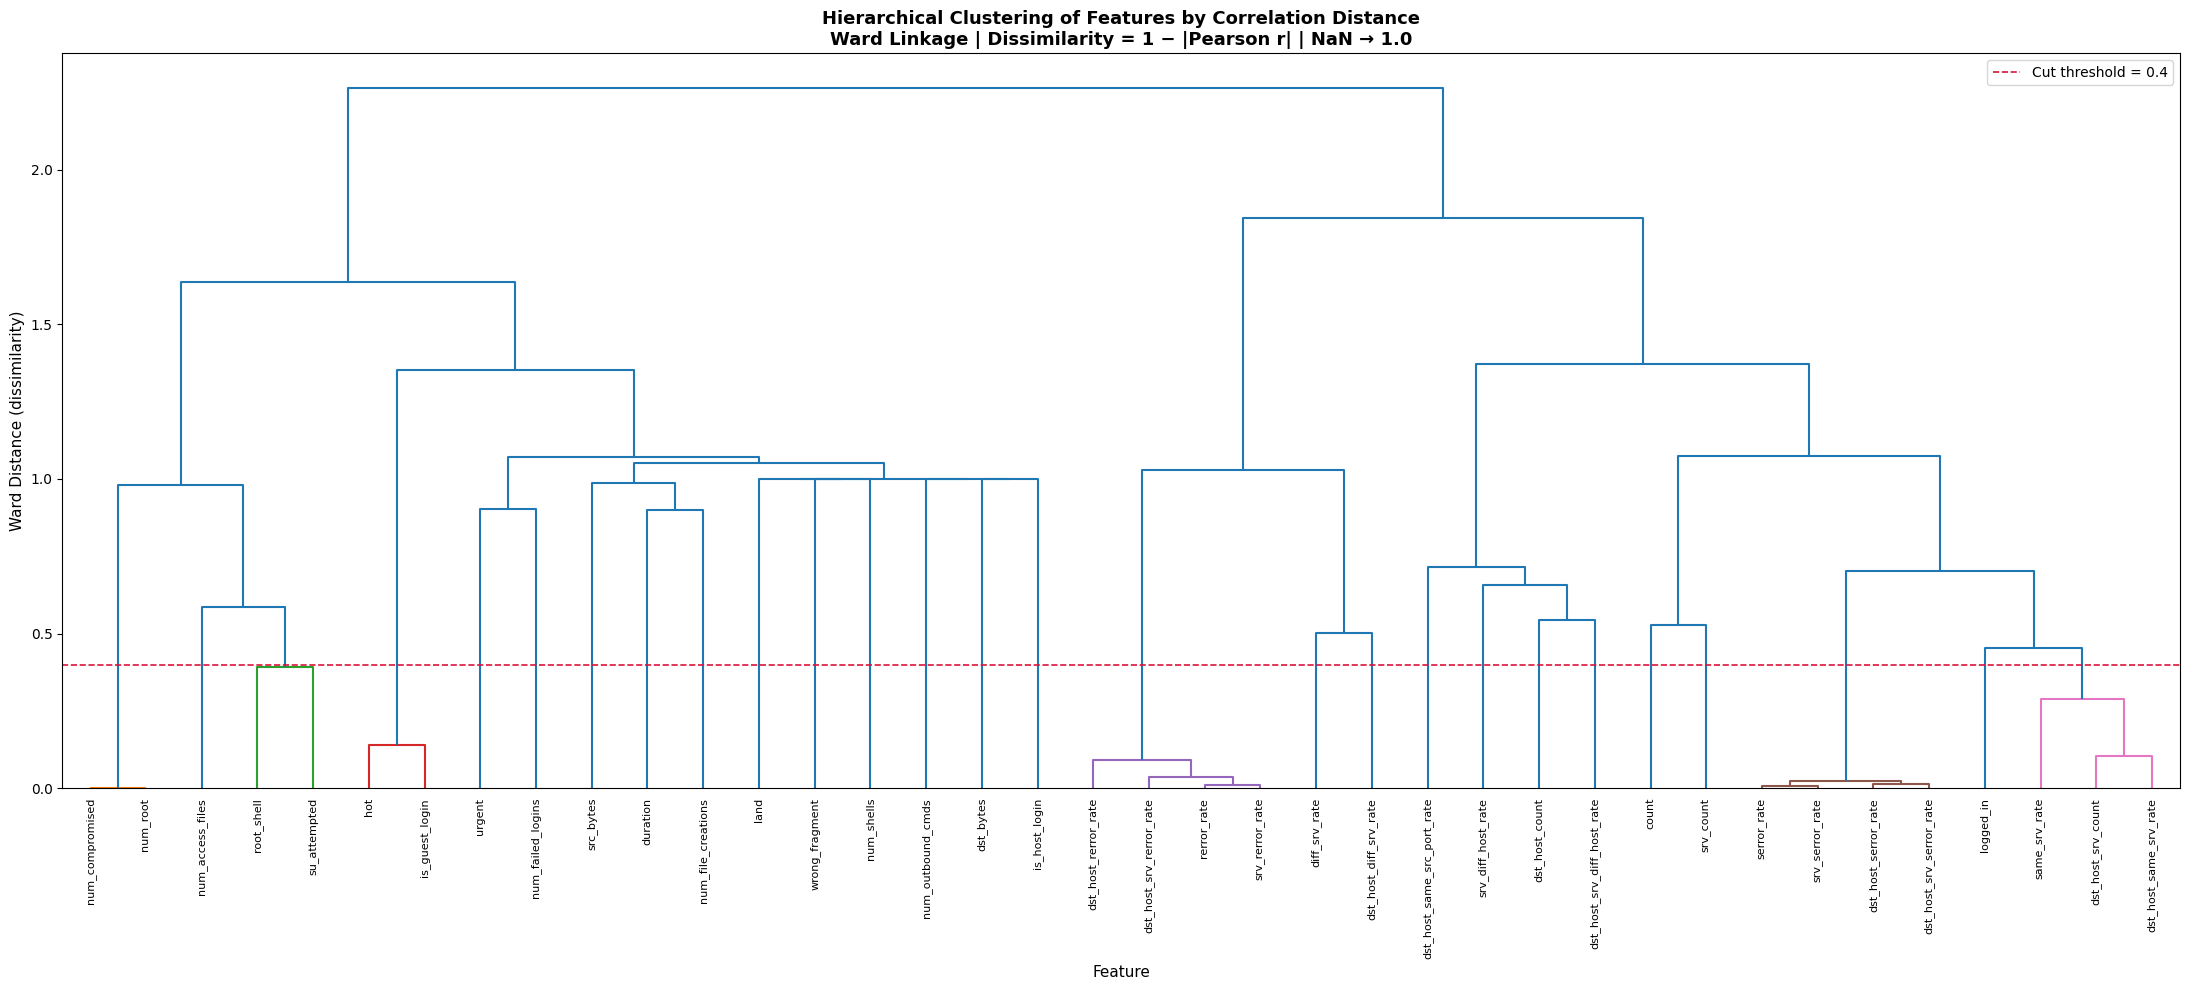


Cluster assignments at distance threshold 0.4:
                    feature  cluster
                   num_root        1
            num_compromised        1
                 root_shell        2
               su_attempted        2
           num_access_files        3
                        hot        4
             is_guest_login        4
                     urgent        5
          num_failed_logins        6
                   duration        7
         num_file_creations        8
                  src_bytes        9
             wrong_fragment       10
                 num_shells       11
                       land       12
                  dst_bytes       13
              is_host_login       14
          num_outbound_cmds       15
            srv_rerror_rate       16
                rerror_rate       16
       dst_host_rerror_rate       16
   dst_host_srv_rerror_rate       16
              diff_srv_rate       17
     dst_host_diff_srv_rate       18
             dst_host_count

In [28]:
# Compute correlation on numeric features only
numeric_cols=train_df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix=train_df[numeric_cols].corr(method='pearson')

# Hierarchical clustering on the correlation matrix
# This reorders features so correlated groups cluster together visually
# Method: ward linkage minimizes within-cluster variance
dissimilarity=1 - corr_matrix.abs()
dissimilarity_filled=dissimilarity.fillna(1.0)


dissimilarity_sym=(dissimilarity_filled + dissimilarity_filled.T)/2
# Manually handling NaNs as np.fill_diagonal needs write-allowed underlying array
dissimilarity_sym_arr=dissimilarity_sym.to_numpy().copy()
np.fill_diagonal(dissimilarity_sym_arr, 0.0)
dissimilarity_sym = pd.DataFrame(
    dissimilarity_sym_arr,
    index=dissimilarity_sym.index,
    columns=dissimilarity_sym.columns
)

assert not dissimilarity_sym.isnull().any().any(), "NaNs remain after fill"

assert np.allclose(dissimilarity_sym, dissimilarity_sym.T, atol=1e-10), \
    "Matrix not symmetric"

assert np.allclose(np.diag(dissimilarity_sym.values), 0, atol=1e-10), \
    "Diagonal not zero"

print("Dissimilarity matrix validated. Shape:", dissimilarity_sym.shape)
print("NaN count:", dissimilarity_sym.isnull().sum().sum())
print("Max asymmetry:", (dissimilarity_sym - dissimilarity_sym.T).abs().max().max())

condensed=squareform(dissimilarity_sym.values, checks=True)
Z=linkage(condensed, method='ward')

fig, ax=plt.subplots(figsize=(22, 10))

dendrogram(
    Z,
    labels=dissimilarity_sym.columns.tolist(),
    leaf_rotation=90,
    leaf_font_size=8,
    color_threshold=0.4,   # cut line — clusters with distance < 0.4 are same color
    ax=ax
)

ax.axhline(y=0.4, color='crimson', linestyle='--', linewidth=1.2, label='Cut threshold = 0.4')
ax.set_title(
    'Hierarchical Clustering of Features by Correlation Distance\n'
    'Ward Linkage | Dissimilarity = 1 − |Pearson r| | NaN → 1.0',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Feature', fontsize=11)
ax.set_ylabel('Ward Distance (dissimilarity)', fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../outputs/stage3b_hierarchical_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

# ! Extract cluster assignments at the chosen cut threshold
# fcluster() cuts the dendrogram at the specified distance and assigns
# each feature a cluster label. This gives us named redundancy groups
# that will directly inform Stage 4 drop/merge decisions.

cluster_labels=fcluster(Z, t=0.4, criterion='distance')
cluster_df = pd.DataFrame({
    'feature': dissimilarity_sym.columns.tolist(),
    'cluster': cluster_labels
}).sort_values('cluster')

print("\nCluster assignments at distance threshold 0.4:")
print(cluster_df.to_string(index=False))

In [75]:
# Extract all pairs with |r| > 0.85 — these are redundancy candidates
# We use the upper triangle only to avoid duplicate pairs

print("<--- HIGH CORRELATION PAIRS (|r| > 0.85)", f"{"-"*35}>\n")

high_corr_pairs=[]

for i in range(len(numeric_cols)):
    for j in range(i + 1, len(numeric_cols)):
        r=corr_matrix.iloc[i, j]
        if abs(r) > 0.85:
            high_corr_pairs.append({
                'feature_A': numeric_cols[i],
                'feature_B': numeric_cols[j],
                'pearson_r': round(r, 4),
                'abs_r': round(abs(r), 4)
            })

high_corr_df=pd.DataFrame(high_corr_pairs).sort_values('abs_r', ascending=False)
print(high_corr_df.to_string(index=False))
print(f"\nTotal high-correlation pairs: {len(high_corr_df)}")

<--- HIGH CORRELATION PAIRS (|r| > 0.85) ----------------------------------->

           feature_A                feature_B  pearson_r  abs_r
     num_compromised                 num_root     0.9988 0.9988
         serror_rate          srv_serror_rate     0.9933 0.9933
         rerror_rate          srv_rerror_rate     0.9890 0.9890
     srv_serror_rate dst_host_srv_serror_rate     0.9863 0.9863
dst_host_serror_rate dst_host_srv_serror_rate     0.9851 0.9851
         serror_rate dst_host_srv_serror_rate     0.9811 0.9811
         serror_rate     dst_host_serror_rate     0.9794 0.9794
     srv_serror_rate     dst_host_serror_rate     0.9776 0.9776
     srv_rerror_rate dst_host_srv_rerror_rate     0.9702 0.9702
         rerror_rate dst_host_srv_rerror_rate     0.9644 0.9644
         rerror_rate     dst_host_rerror_rate     0.9267 0.9267
dst_host_rerror_rate dst_host_srv_rerror_rate     0.9247 0.9247
     srv_rerror_rate     dst_host_rerror_rate     0.9178 0.9178
  dst_host_srv_count   ds

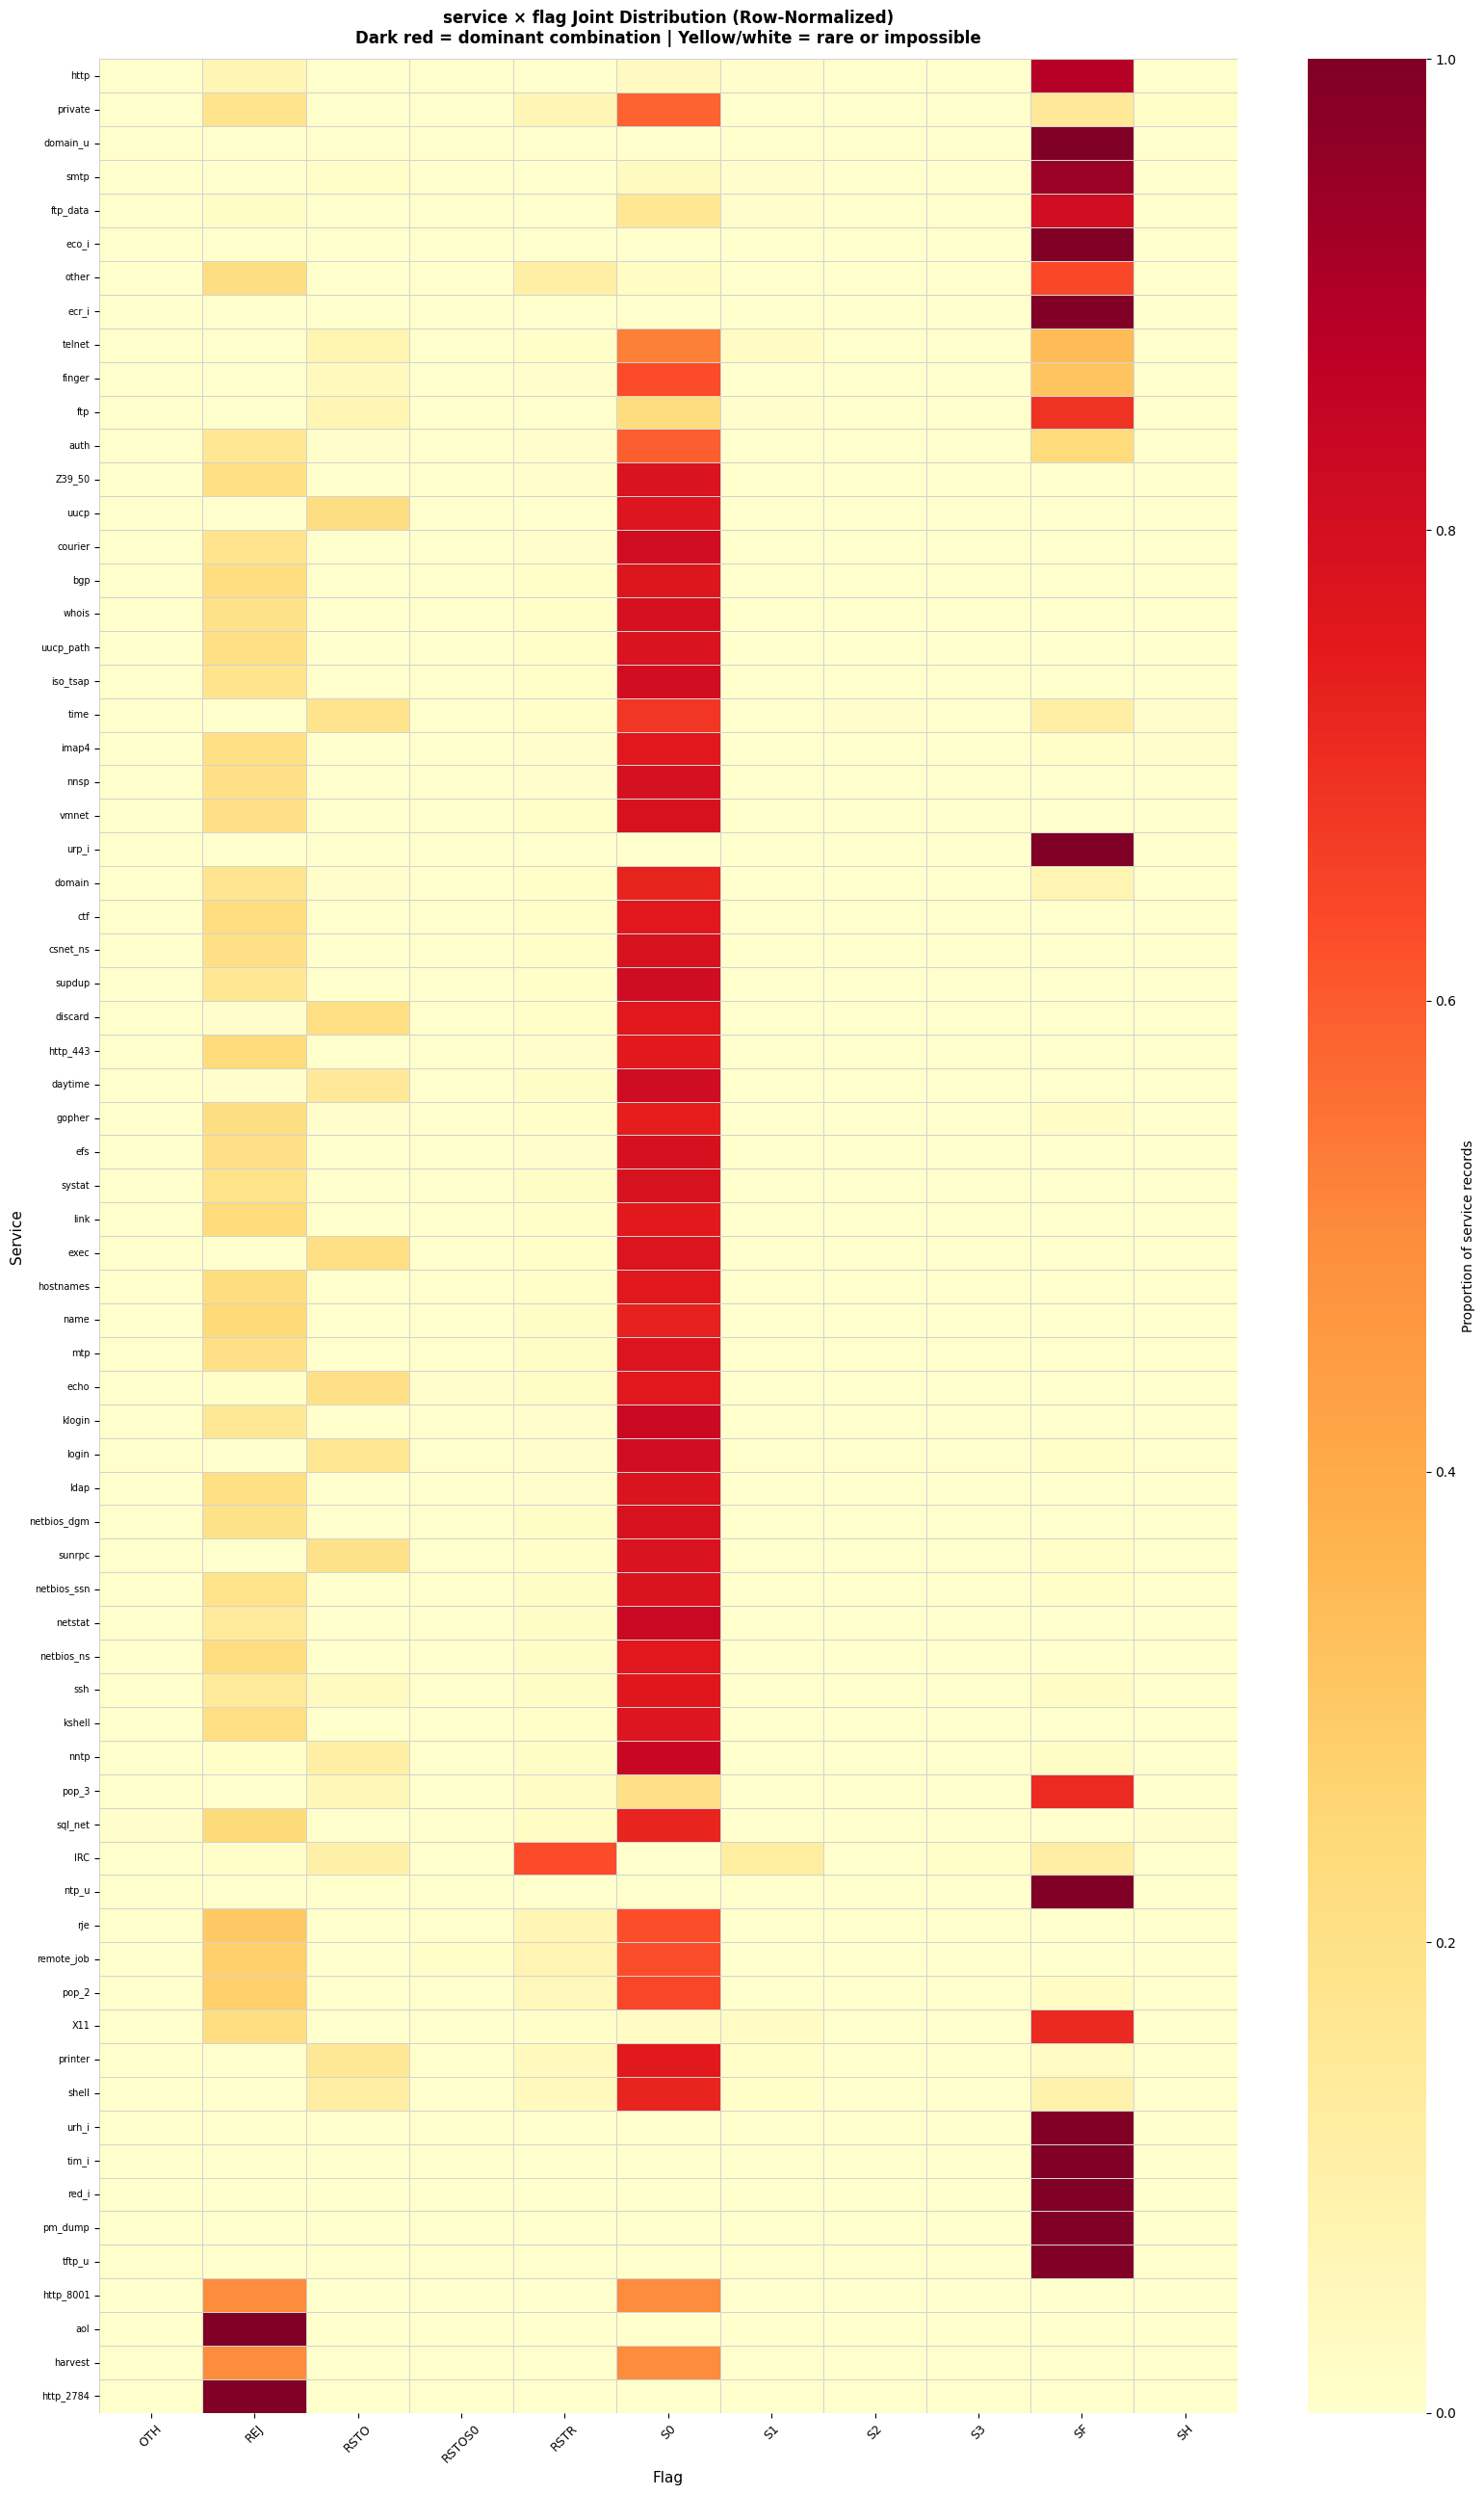

In [24]:
# This is the most domain-meaningful bivariate analysis in the dataset.
# Certain service/flag combinations are structurally impossible in
# normal traffic. For example:
#   - icmp connections cannot have flag=SF (successful TCP handshake)
#     because ICMP doesn't use TCP handshakes
#   - S0 flag (connection attempt, no response) on http is a SYN flood signature
#   - REJ on certain services indicates port scanning (Probe attack pattern)
#
# We compute a frequency cross-tabulation and visualize as a heatmap.
# Cells with zero or near-zero frequency are potential hard anomaly indicators.

# Cross-tabulation: rows=service, cols=flag
cross_tab=pd.crosstab(train_df['service'], train_df['flag'])

# Normalize by row so each service sums to 1
# This makes the pattern readable regardless of service frequency
cross_tab_norm=cross_tab.div(cross_tab.sum(axis=1), axis=0)

# Sort services by total frequency for readability
service_order=train_df['service'].value_counts().index.tolist()
cross_tab_norm=cross_tab_norm.reindex(service_order)

fig, ax=plt.subplots(figsize=(16, 26))

sns.heatmap(
    cross_tab_norm,
    ax=ax,
    cmap='YlOrRd',      # yellow=rare, red=dominant combination
    linewidths=0.4,
    linecolor='lightgrey',
    cbar_kws={'label': 'Proportion of service records'},
    annot=False         # too dense — use mask visualization below
)

ax.set_title(
    'service × flag Joint Distribution (Row-Normalized)\n'
    'Dark red = dominant combination | Yellow/white = rare or impossible',
    fontsize=12, fontweight='bold', pad=12
)
ax.set_xlabel('Flag', fontsize=11)
ax.set_ylabel('Service', fontsize=11)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=7)

plt.tight_layout()
plt.savefig('../outputs/stage3b_service_flag_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# Now extract combinations that are RARE (< 0.5% of a service's records)
# but NON-ZERO — these are the suspicious edge cases we want to flag
# as potential anomaly-informative combinations

print("<--- RARE SERVICE×FLAG COMBINATIONS (non-zero but < 0.5%)", f"{"-"*35}>\n")
print("These combinations almost never appear in this training data")
print("and warrant treatment as anomaly-informative during feature engineering\n")

rare_combos=[]

for service in cross_tab_norm.index:
    for flag in cross_tab_norm.columns:
        pct=cross_tab_norm.loc[service, flag]
        raw_count=cross_tab.loc[service, flag] if flag in cross_tab.columns else 0
        if 0<pct<0.005:
            rare_combos.append({
                'service': service,
                'flag': flag,
                'proportion': round(pct, 5),
                'raw_count': raw_count
            })

rare_df=pd.DataFrame(rare_combos).sort_values('proportion')
print(rare_df.head(40).to_string(index=False))

<--- RARE SERVICE×FLAG COMBINATIONS (non-zero but < 0.5%) ----------------------------------->

These combinations almost never appear in this training data
and warrant treatment as anomaly-informative during feature engineering

  service   flag  proportion  raw_count
     http     SH     0.00002          1
     http RSTOS0     0.00005          2
  private     S1     0.00005          1
     http    OTH     0.00010          4
     smtp     SH     0.00014          1
 ftp_data RSTOS0     0.00015          1
 ftp_data     SH     0.00015          1
    other     S3     0.00023          1
     smtp    OTH     0.00027          2
     smtp RSTOS0     0.00027          2
 ftp_data    OTH     0.00029          2
     smtp    REJ     0.00041          3
     http     S3     0.00042         17
   telnet     SH     0.00042          1
    other    OTH     0.00046          2
   finger     SH     0.00057          1
      ftp     S2     0.00057          1
   finger     S3     0.00057          1
      ftp 

In [21]:
# VIF measures multicollinearity — how much a feature's variance
# is explained by linear combinations of other features.
# VIF = 1:    no multicollinearity
# VIF = 5-10: moderate (worth noting)
# VIF > 10:   high — this feature is largely redundant given others
# VIF > 100:  severe — near-perfect linear combination exists
#
# WHY THIS MATTERS FOR ONE-CLASS SVM:
# OCSVM builds a kernel (RBF) distance matrix between samples.
# When features are highly collinear, the effective dimensionality
# of your feature space is lower than it appears, and the kernel
# matrix becomes ill-conditioned — the model's boundary becomes
# unreliable in the directions of high collinearity.

# Use only continuous numeric features — VIF is a regression concept
# and doesn't apply to binary flags or near-constants
numeric_cols=train_df.select_dtypes(include=[np.number]).columns.tolist()
vif_candidates = [
    col for col in numeric_cols
    if train_df[col].nunique() > 10
    and train_df[col].var() > 0.01
]

print(f"Computing VIF on {len(vif_candidates)} continuous features...\n")

vif_data=train_df[vif_candidates].copy()

# VIF computation can be unstable with extreme values
# Apply log1p to confirmed heavy-tail features before computing
# so VIF reflects the relationship structure, not tail dominance
for col in ['src_bytes', 'dst_bytes', 'duration', 'srv_count']:
    if col in vif_data.columns:
        vif_data[col] = np.log1p(vif_data[col])

vif_results=[]
for i, col in enumerate(vif_candidates):
    try:
        vif_val = variance_inflation_factor(vif_data.values, i)
        vif_results.append({'feature': col, 'VIF': round(vif_val, 2)})
    except Exception as e:
        vif_results.append({'feature': col, 'VIF': None})

vif_df = pd.DataFrame(vif_results).sort_values('VIF', ascending=False)
print(vif_df.to_string(index=False))

# Flag high VIF features
high_vif = vif_df[vif_df['VIF'] > 10]['feature'].tolist()
print(f"\nHigh VIF features (>10): {high_vif}")

Computing VIF on 26 continuous features...

                    feature    VIF
                   num_root 431.73
            num_compromised 431.51
            srv_serror_rate 171.65
                serror_rate 143.73
   dst_host_srv_serror_rate  85.48
            srv_rerror_rate  75.61
                rerror_rate  71.58
       dst_host_serror_rate  60.09
     dst_host_same_srv_rate  28.06
   dst_host_srv_rerror_rate  23.07
              same_srv_rate  22.05
         dst_host_srv_count  17.42
       dst_host_rerror_rate  10.37
                  src_bytes   9.38
                  srv_count   8.37
                  dst_bytes   8.22
             dst_host_count   7.87
                      count   4.31
     dst_host_diff_srv_rate   3.17
dst_host_same_src_port_rate   2.90
              diff_srv_rate   2.03
                   duration   1.82
dst_host_srv_diff_host_rate   1.79
         srv_diff_host_rate   1.47
                        hot   1.12
         num_file_creations   1.03

High VIF f

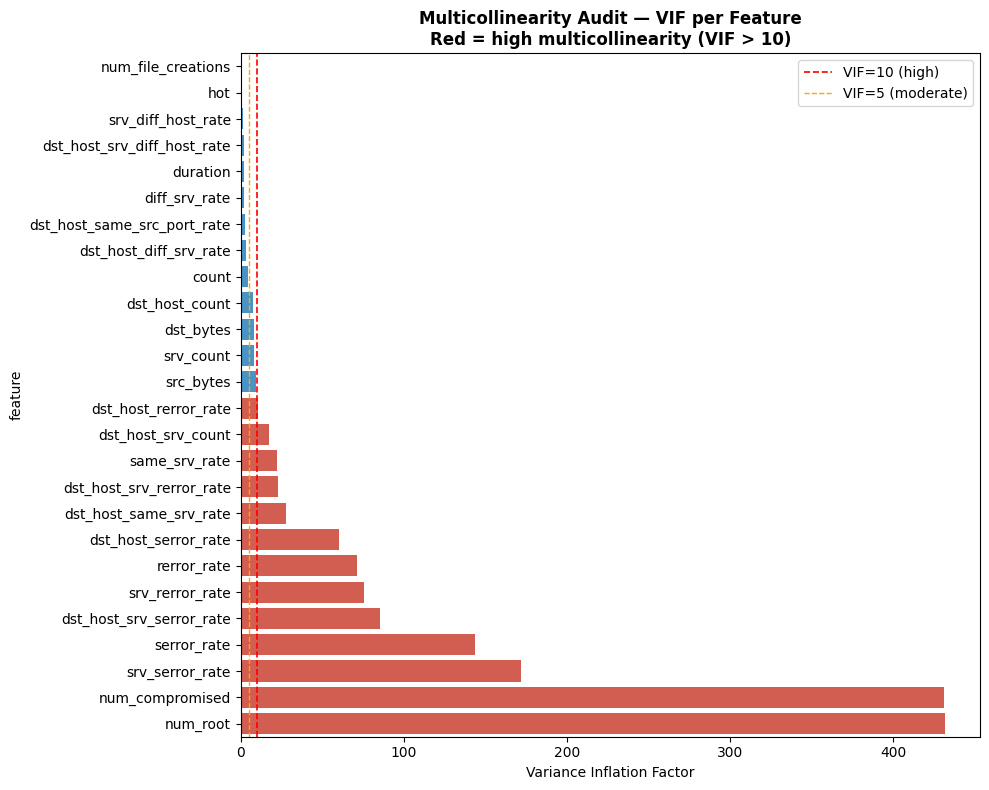

In [22]:
# Visualize VIF scores
plt.figure(figsize=(10, 8))

vif_plot = vif_df.dropna().sort_values('VIF', ascending=True)
colors = ['#e74c3c' if v > 10 else '#3498db' for v in vif_plot['VIF']]

sns.barplot(x='VIF', y='feature', data=vif_plot,
            palette=colors, orient='h')

plt.axvline(x=10,  color='red',    linestyle='--', lw=1.2, label='VIF=10 (high)')
plt.axvline(x=5,   color='orange', linestyle='--', lw=1.0, label='VIF=5 (moderate)')

plt.xlabel('Variance Inflation Factor')
plt.title('Multicollinearity Audit — VIF per Feature\n'
          'Red = high multicollinearity (VIF > 10)', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/stage3b_vif_audit.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
print("""
STAGE 3B FINDINGS — BIVARIATE & MULTIVARIATE ANALYSIS
══════════════════════════════════════════════════════

── HIGH CORRELATION PAIRS (|r| > 0.85) ──────────────────
15 pairs identified. Key groups:
  • num_root ↔ num_compromised          r = 0.9988
  • Full serror family (4 features)     r = 0.977–0.993
  • Full rerror family (4 features)     r = 0.918–0.989
  • dst_host_srv_count ↔ dst_host_same_srv_rate  r = 0.897
  • hot ↔ is_guest_login                r = 0.860

── SERVICE × FLAG HEATMAP ────────────────────────────────
Dominant normal signature: http→SF, most TCP services→SF
Attack-informative patterns:
  • S0 dominance in harvest/aol/nttp_8001 → SYN flood / scan targets
  • REJ pattern across many services → Probe (port scan) signature
  • IRC dual-mode (SF + RSTO) → C2 channel indicator
  • pop_3 / ntp_u secondary S4 mass → credential-probe behavior

Rare combinations catalogued (41 pairs, proportion < 0.5%):
  • http→SH (1 record), smtp→REJ (3 records) are near-impossible
    in normal traffic — strong anomaly indicators at test time
  • These will inform a binary "is_rare_service_flag" engineered
    feature in Stage 4

── VIF AUDIT ─────────────────────────────────────────────
Three tiers identified:
  Tier 1 (VIF > 100): num_root(431), num_compromised(431),
    srv_serror_rate(171), serror_rate(143) — catastrophic
  Tier 2 (VIF 10–100): full rerror/serror dst_host variants,
    same_srv_rate family, dst_host_srv_count — high
  Tier 3 (VIF < 5): count, diff_srv_rate, duration,
    srv_diff_host_rate, hot, num_file_creations — clean

── HIERARCHICAL CLUSTERING ───────────────────────────────
Cut threshold: 0.4 | Method: Ward | Distance: 1 − |r|
27 clusters identified from 38 features

CONFIRMED DROP LIST (redundant, cluster-internal):
  • num_root           (cluster 1 — dominated by num_compromised)
  • srv_rerror_rate    (cluster 16 — retain rerror_rate)
  • dst_host_rerror_rate     (cluster 16)
  • dst_host_srv_rerror_rate (cluster 16)
  • srv_serror_rate    (cluster 25 — retain serror_rate)
  • dst_host_serror_rate     (cluster 25)
  • dst_host_srv_serror_rate (cluster 25)
  • dst_host_same_srv_rate   (cluster 26 — retain same_srv_rate)

Total features to drop: 8
Remaining continuous features after drop: 30 (before categorical encoding)

RETAIN WITH AWARENESS (correlated but non-redundant):
  • root_shell + su_attempted (cluster 2) — U2R co-signal
  • hot + is_guest_login (cluster 4) — scale-differentiated
  • dst_host_srv_count (cluster 26) — scope-differentiated from
    same_srv_rate despite proximity

STRUCTURAL FINDING:
  Dendrogram top-level split confirms two informationally
  distinct feature worlds:
    Left branch  → behavioral/content indicators (sparse, binary)
    Right branch → traffic/rate/volume features (continuous)
  This bifurcation will inform Autoencoder input stream design
  in Stage 5 — potentially two encoder pathways.

── STAGE 4 PREPROCESSING DECISIONS LOCKED ───────────────
  1. Drop 8 confirmed redundant features
  2. Engineer binary "is_rare_service_flag" from heatmap analysis
  3. Retain all behavioral singletons as pass-through features
  4. serror_rate and rerror_rate are the canonical error signals
══════════════════════════════════════════════════════
""")


STAGE 3B FINDINGS — BIVARIATE & MULTIVARIATE ANALYSIS
══════════════════════════════════════════════════════

── HIGH CORRELATION PAIRS (|r| > 0.85) ──────────────────
15 pairs identified. Key groups:
  • num_root ↔ num_compromised          r = 0.9988
  • Full serror family (4 features)     r = 0.977–0.993
  • Full rerror family (4 features)     r = 0.918–0.989
  • dst_host_srv_count ↔ dst_host_same_srv_rate  r = 0.897
  • hot ↔ is_guest_login                r = 0.860

── SERVICE × FLAG HEATMAP ────────────────────────────────
Dominant normal signature: http→SF, most TCP services→SF
Attack-informative patterns:
  • S0 dominance in harvest/aol/nttp_8001 → SYN flood / scan targets
  • REJ pattern across many services → Probe (port scan) signature
  • IRC dual-mode (SF + RSTO) → C2 channel indicator
  • pop_3 / ntp_u secondary S4 mass → credential-probe behavior

Rare combinations catalogued (41 pairs, proportion < 0.5%):
  • http→SH (1 record), smtp→REJ (3 records) are near-impossible
 

# Stage 3-C UMAP Visuals

In [22]:
print("<--- UMAP Theory", f"{"-"*35}>")
print("""
UMAP requires a fully numeric matrix. We do MINIMAL preprocessing here just enough to make the data numeric. This is NOT the Stage 4 pipeline.
The point of this UMAP is to visualize the RAW feature space structure before any engineering decisions. We use StandardScaler here purely
for numerical stability in UMAP's distance computations, NOT as a preprocessing decision.

Frequency-encode categoricals minimally (not OHE, we want compactness)
Frequency encoding maps each category to its frequency in the training set.
This is used here for visualization only.""")

df_viz=train_df.copy()
for col in ['protocol_type', 'service', 'flag']:
    freq=df_viz[col].value_counts(normalize=True)
    df_viz[col] = df_viz[col].map(freq)

scaler=StandardScaler()
X_raw=scaler.fit_transform(df_viz.values)

#UMAP on 125k records is slow. We subsample 20k stratified by label
np.random.seed(42)
sample_idx=np.random.choice(len(X_raw), size=20000, replace=False)
X_sample=X_raw[sample_idx]
y_sample=train_labels['label'].iloc[sample_idx].values

# UMAP Setup. n=30 is standard
reducer=umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    n_components=2,
    metric='euclidean',
    random_state=42,
    verbose=True
)

embedding=reducer.fit_transform(X_sample)
print("UMAP embedding shape:", embedding.shape)

print("<--- UMAP Embeddings Created",f"{"-"*35}>")

<--- UMAP Theory ----------------------------------->

UMAP requires a fully numeric matrix. We do MINIMAL preprocessing here just enough to make the data numeric. This is NOT the Stage 4 pipeline.
The point of this UMAP is to visualize the RAW feature space structure before any engineering decisions. We use StandardScaler here purely
for numerical stability in UMAP's distance computations, NOT as a preprocessing decision.

Frequency-encode categoricals minimally (not OHE, we want compactness)
Frequency encoding maps each category to its frequency in the training set.
This is used here for visualization only.
UMAP(n_jobs=1, n_neighbors=30, random_state=42, verbose=True)
Mon Apr 13 22:38:02 2026 Construct fuzzy simplicial set
Mon Apr 13 22:38:02 2026 Finding Nearest Neighbors
Mon Apr 13 22:38:02 2026 Building RP forest with 12 trees
Mon Apr 13 22:38:02 2026 NN descent for 14 iterations
	 1  /  14
	 2  /  14
	 3  /  14
	Stopping threshold met -- exiting after 3 iterations
Mon Apr 13 22:3

Epochs completed:   2%| ██                                                                                5/200 [00:00]

	completed  0  /  200 epochs


Epochs completed:  13%| ██████████▍                                                                      26/200 [00:01]

	completed  20  /  200 epochs


...

	completed  160  /  200 epochs


Epochs completed:  93%| █████████████████████████████████████████████████████████████████████████▍      186/200 [00:10]

	completed  180  /  200 epochs


Epochs completed: 100%| ███████████████████████████████████████████████████████████████████████████████ 200/200 [00:10]

Mon Apr 13 22:38:18 2026 Finished embedding
UMAP embedding shape: (20000, 2)
<--- UMAP Embeddings Created ----------------------------------->


In [23]:
print("<--- UMAP Visualization Setup",f"{"-"*35}>")
print("UMAP embedding shape:", embedding.shape)

print(embedding.shape)
print(embedding[:, 0].shape)
print(y_sample.shape)

umap_df=pd.DataFrame({
    'UMAP_1': embedding[:, 0],
    'UMAP_2': embedding[:, 1],
    'label': y_sample
})

# Define color palette — normal gets a neutral color, each attack type distinct
palette = {
    'normal':'#AAAAAA',
    'DoS':'#E74C3C',
    'Probe':'#3498DB',
    'R2L':'#F39C12',
    'U2R':'#9B59B6'
}

# Map raw labels to category groups
# Adjust this mapping if the label column has full attack names vs categories
def map_label(x):
    x=str(x).strip().lower()
    if x=='normal':
        return 'normal'
    # NSL-KDD stores category directly in the label column
    # If stored as specific attack names, add mapping here
    return x

umap_df['label_group']=umap_df['label'].apply(map_label)
print("<--- UMAP Visualization Setup Complete",f"{"-"*35}>")

<--- UMAP Visualization Setup ----------------------------------->
UMAP embedding shape: (20000, 2)
(20000, 2)
(20000,)
(20000,)
<--- UMAP Visualization Setup Complete ----------------------------------->


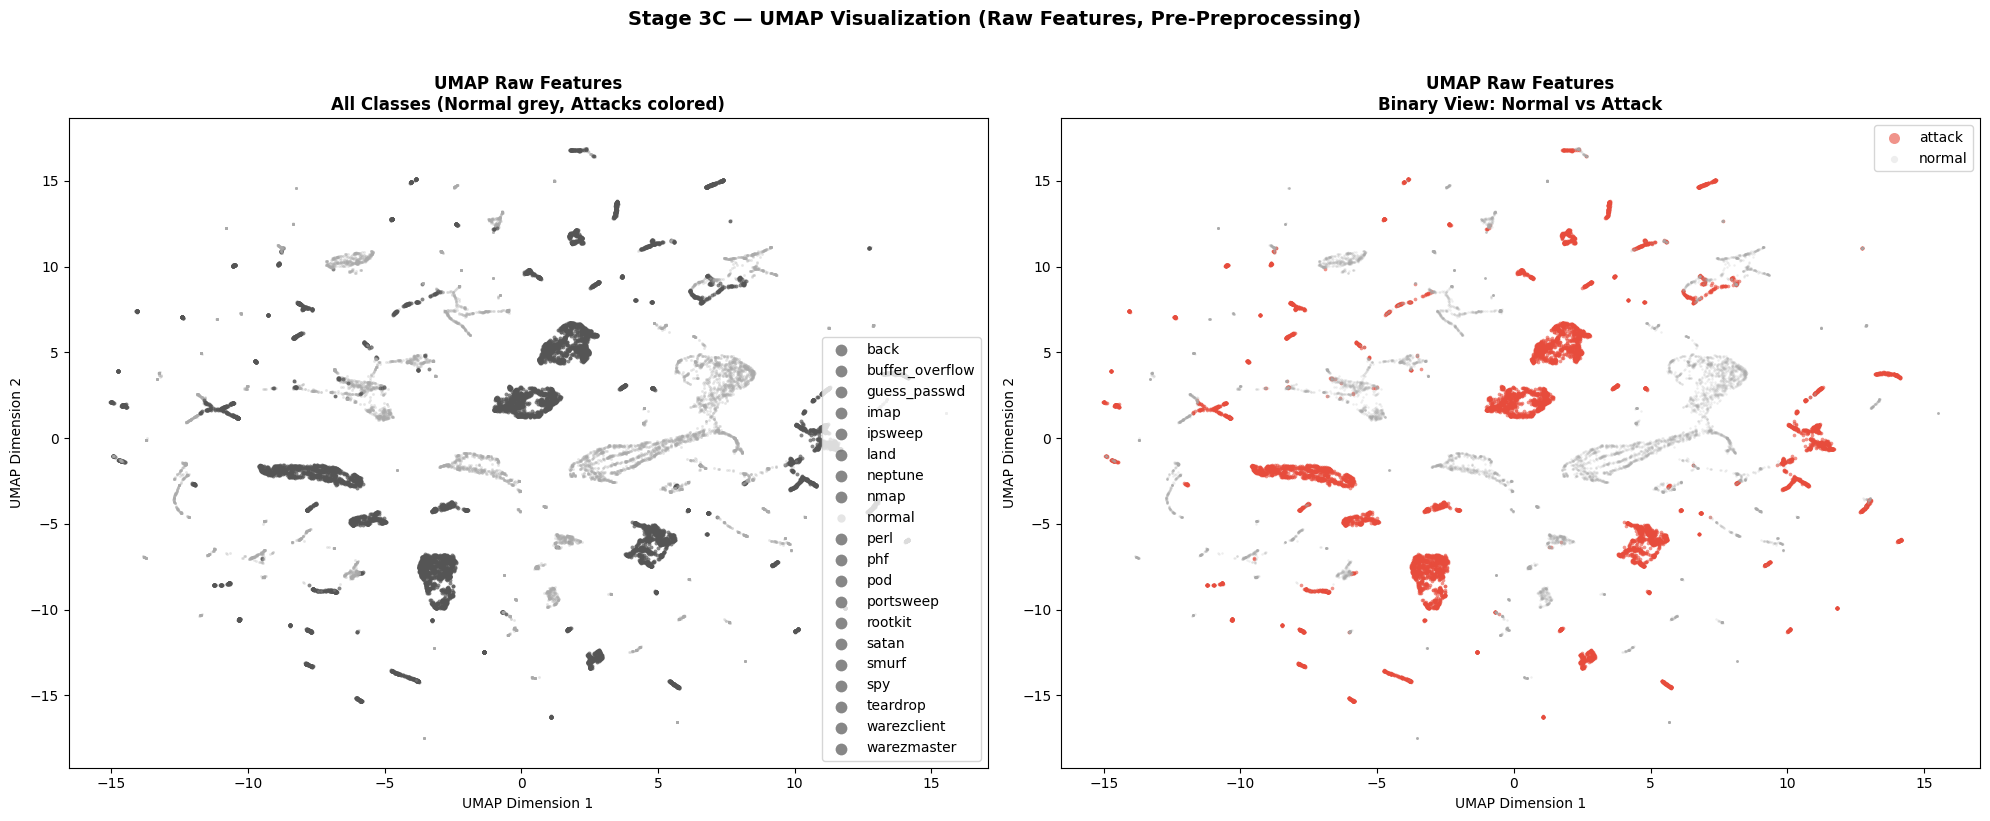

In [24]:
fig, axes=plt.subplots(1,2, figsize=(20,8))
ax=axes[0]
for label, group in umap_df.groupby('label_group'):
    color = palette.get(label, '#555555')
    alpha = 0.3 if label == 'normal' else 0.7
    size = 4 if label == 'normal' else 8
    ax.scatter(group['UMAP_1'], group['UMAP_2'], c=color, label=label, alpha=alpha, s=size, linewidths=0)

ax.set_title('UMAP Raw Features\nAll Classes (Normal grey, Attacks colored)', fontsize=12, fontweight='bold')
ax.set_xlabel('UMAP Dimension 1')
ax.set_ylabel('UMAP Dimension 2')
ax.legend(markerscale=3, fontsize=10)

ax=axes[1]
umap_df['binary']=umap_df['label_group'].apply(lambda x: 'normal' if x == 'normal' else 'attack')
binary_palette={'normal': '#AAAAAA', 'attack': '#E74C3C'}
for label, group in umap_df.groupby('binary'):
    color=binary_palette[label]
    alpha=0.2 if label == 'normal' else 0.6
    size=3 if label == 'normal' else 7
    ax.scatter(group['UMAP_1'], group['UMAP_2'], c=color, label=label, alpha=alpha, s=size, linewidths=0)

ax.set_title('UMAP Raw Features\nBinary View: Normal vs Attack', fontsize=12, fontweight='bold')
ax.set_xlabel('UMAP Dimension 1')
ax.set_ylabel('UMAP Dimension 2')
ax.legend(markerscale=3, fontsize=10)

plt.suptitle('Stage 3C — UMAP Visualization (Raw Features, Pre-Preprocessing)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/stage3c_umap_raw.png', dpi=150, bbox_inches='tight')
plt.show()


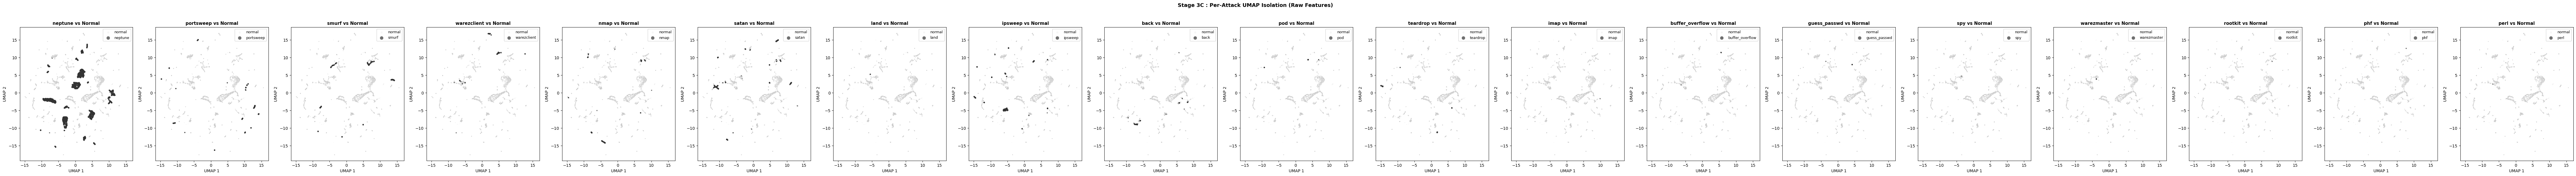

In [29]:
# Per class isolation plot
# Plot each attack type separately against normal background. This reveals which attack categories are geometrically separable from
# normal traffic in raw feature space — critical for predicting which will be hard/easy for unsupervised detectors.

attack_types=[l for l in umap_df['label_group'].unique() if l != 'normal']
fig, axes=plt.subplots(1, len(attack_types), figsize=(6 * len(attack_types), 6))

normal_pts=umap_df[umap_df['label_group'] == 'normal']

for ax, attack in zip(axes, attack_types):
    attack_pts=umap_df[umap_df['label_group'] == attack]
    ax.scatter(normal_pts['UMAP_1'], normal_pts['UMAP_2'], c='#CCCCCC', alpha=0.15, s=3, linewidths=0, label='normal')
    ax.scatter(attack_pts['UMAP_1'], attack_pts['UMAP_2'], c=palette.get(attack, '#333333'), alpha=0.7, s=8, linewidths=0, label=attack)
    ax.set_title(f'{attack} vs Normal', fontsize=11, fontweight='bold')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.legend(markerscale=3, fontsize=9)

plt.suptitle('Stage 3C : Per-Attack UMAP Isolation (Raw Features)', fontsize=13, fontweight='bold', y=1.02)
plt.savefig('../outputs/stage3c_umap_per_attack.png', dpi=250, bbox_inches='tight')
plt.show()

In [ ]:
print("""
STAGE 3C FINDINGS - UMAP Visualization
══════════════════════════════════════════════════════
""")

# Stage 3D - Domain Based Feature Annotation

In [38]:
# For each attack category:
# 1. Define the theoretical feature signature from cybersecurity domain knowledge
# 2. Compute actual distributional differences vs normal traffic
# 3. Annotate findings — confirm or contradict the theoretical prediction
# 4. Flag features that behave unexpectedly (important for model design)

df_analysis=train_df.copy()
df_analysis['attack_category']=train_labels['label'].values
print(df_analysis['attack_category'].unique())
attack_map={
    # DoS
    'back':             'DoS',
    'land':             'DoS',
    'neptune':          'DoS',
    'pod':              'DoS',
    'smurf':            'DoS',
    'teardrop':         'DoS',
    # Probe
    'ipsweep':          'Probe',
    'nmap':             'Probe',
    'portsweep':        'Probe',
    'satan':            'Probe',
    # R2L
    'ftp_write':        'R2L',
    'guess_passwd':     'R2L',
    'imap':             'R2L',
    'multihop':         'R2L',
    'phf':              'R2L',
    'spy':              'R2L',
    'warezclient':      'R2L',
    'warezmaster':      'R2L',
    # U2R
    'buffer_overflow':  'U2R',
    'loadmodule':       'U2R',
    'perl':             'U2R',
    'rootkit':          'U2R',
    # Normal
    'normal':           'normal'
}

df_analysis['attack_category']=(train_labels['label'].str.strip().str.lower().map(attack_map))

# Verify no unmapped values
print(df_analysis['attack_category'].isna().sum())  # should be 0
print(df_analysis['attack_category'].value_counts())

<StringArray>
[         'normal',         'neptune',     'warezclient',         'ipsweep',
       'portsweep',        'teardrop',            'nmap',           'satan',
           'smurf',             'pod',            'back',    'guess_passwd',
       'ftp_write',        'multihop',         'rootkit', 'buffer_overflow',
            'imap',     'warezmaster',             'phf',            'land',
      'loadmodule',             'spy',            'perl']
Length: 23, dtype: str
0
attack_category
normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


<--- Domain Based Feature Annotation ----------------------------------->
   Ratio = attack_median / normal_median  |  >1 = elevated, <1 = suppressed

──────────────────────────────────────────────────
  ATTACK CATEGORY: DoS
──────────────────────────────────────────────────
  Feature                             Predicted    Actual Ratio   Confirmed?
  ─────────────────────────────────── ──────────── ────────────── ──────────
  src_bytes                           ELEVATED     0.000          X CONTRADICTS
    -> High-volume floods send many bytes from attacker
  count                               ELEVATED     43.000         !!
    -> DoS generates massive connection counts to same host
  srv_count                           ELEVATED     2.200          !!
  serror_rate                         ELEVATED     1000000001.000 !!
    -> SYN floods produce SYN errors (no handshake completion)
  srv_serror_rate                     ELEVATED     1000000001.000 !!
  same_srv_rate                    

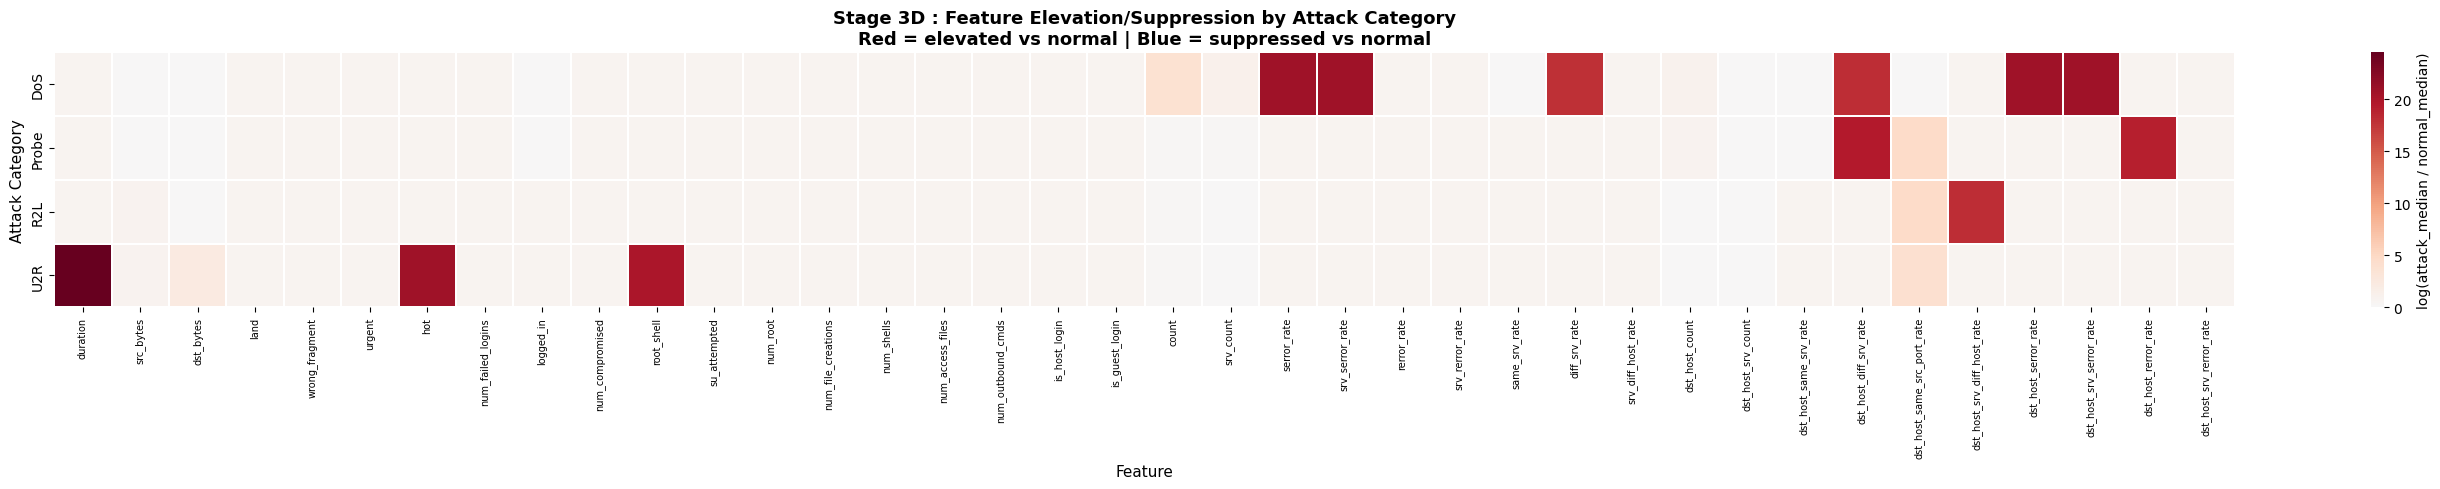

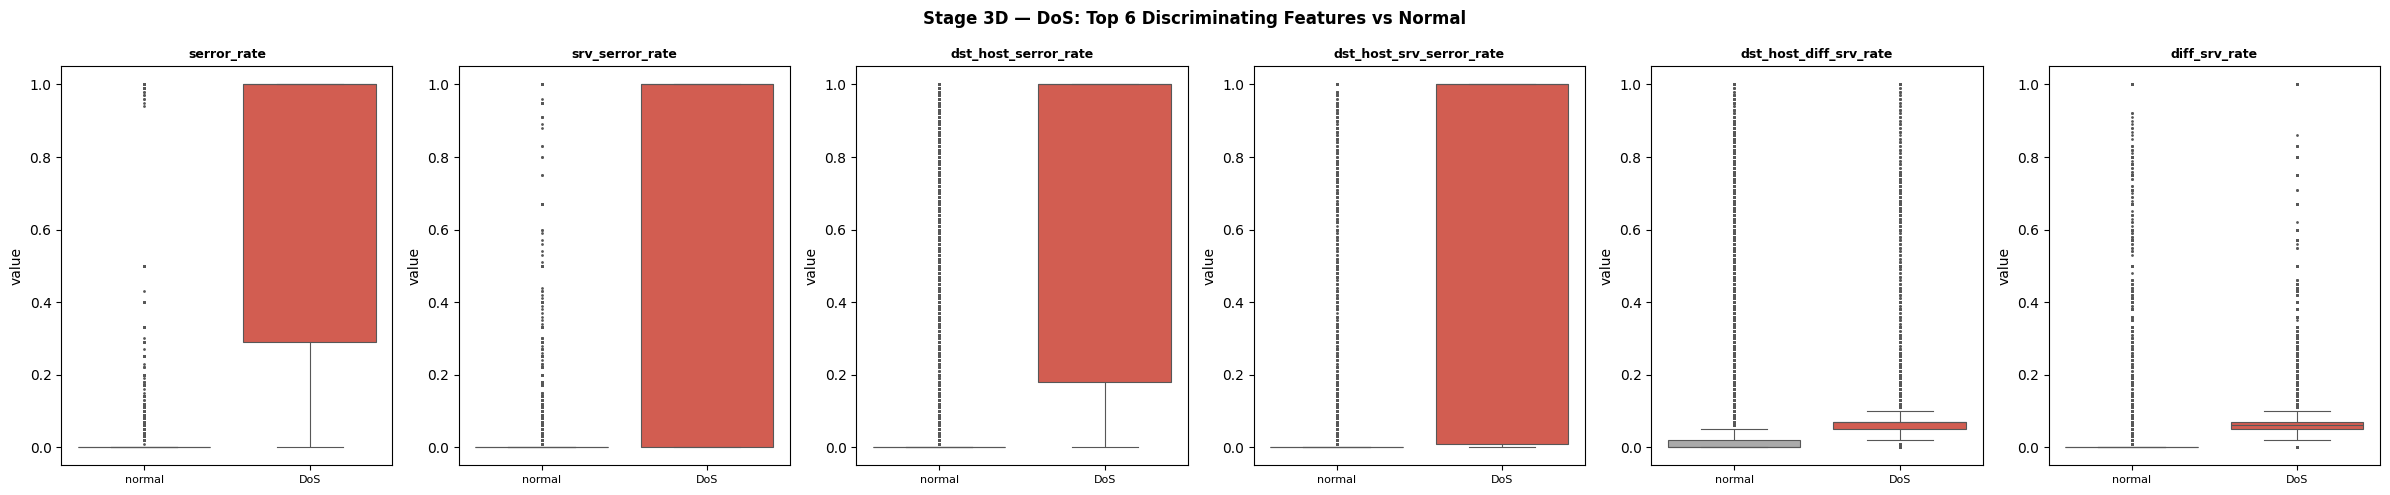

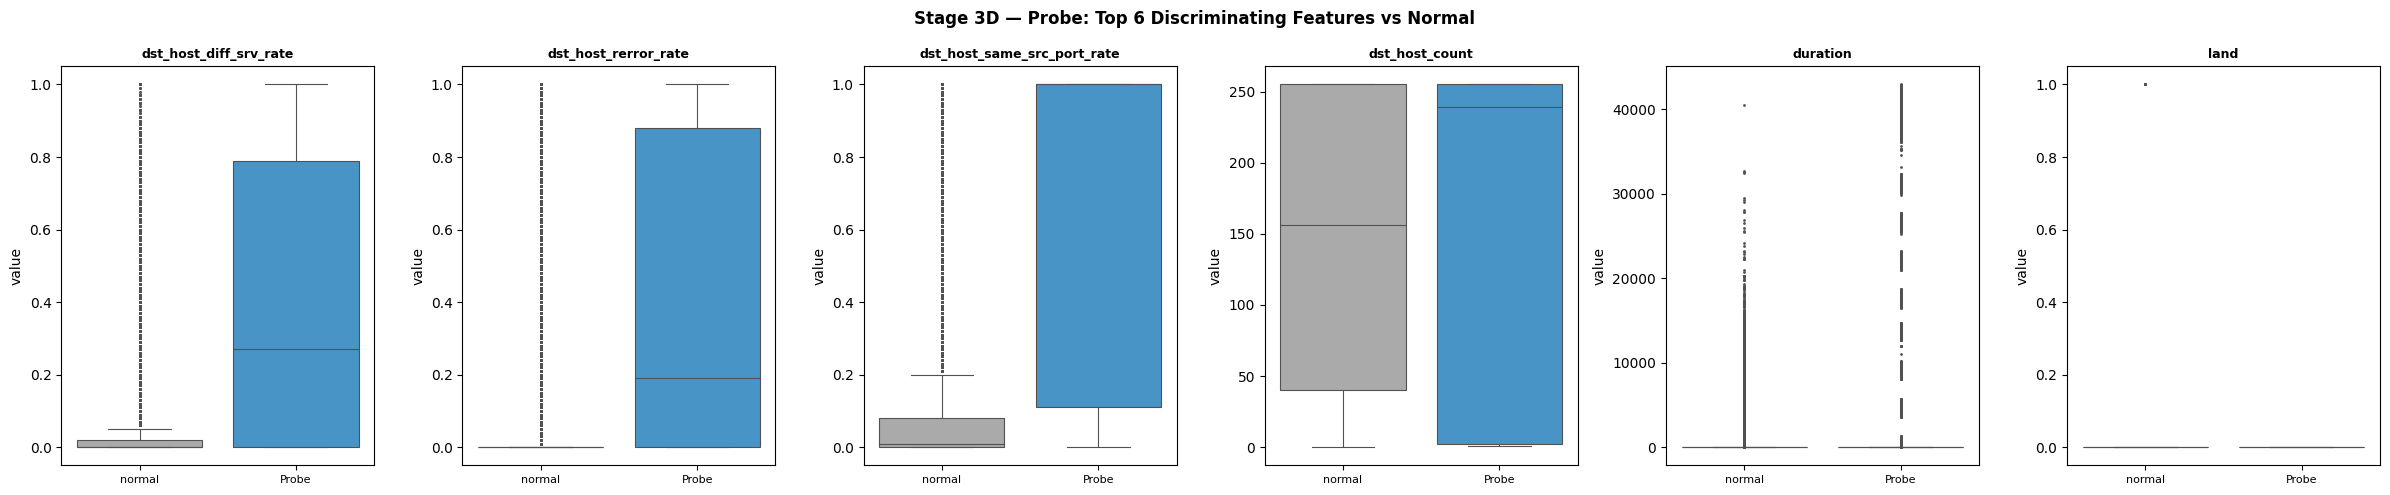

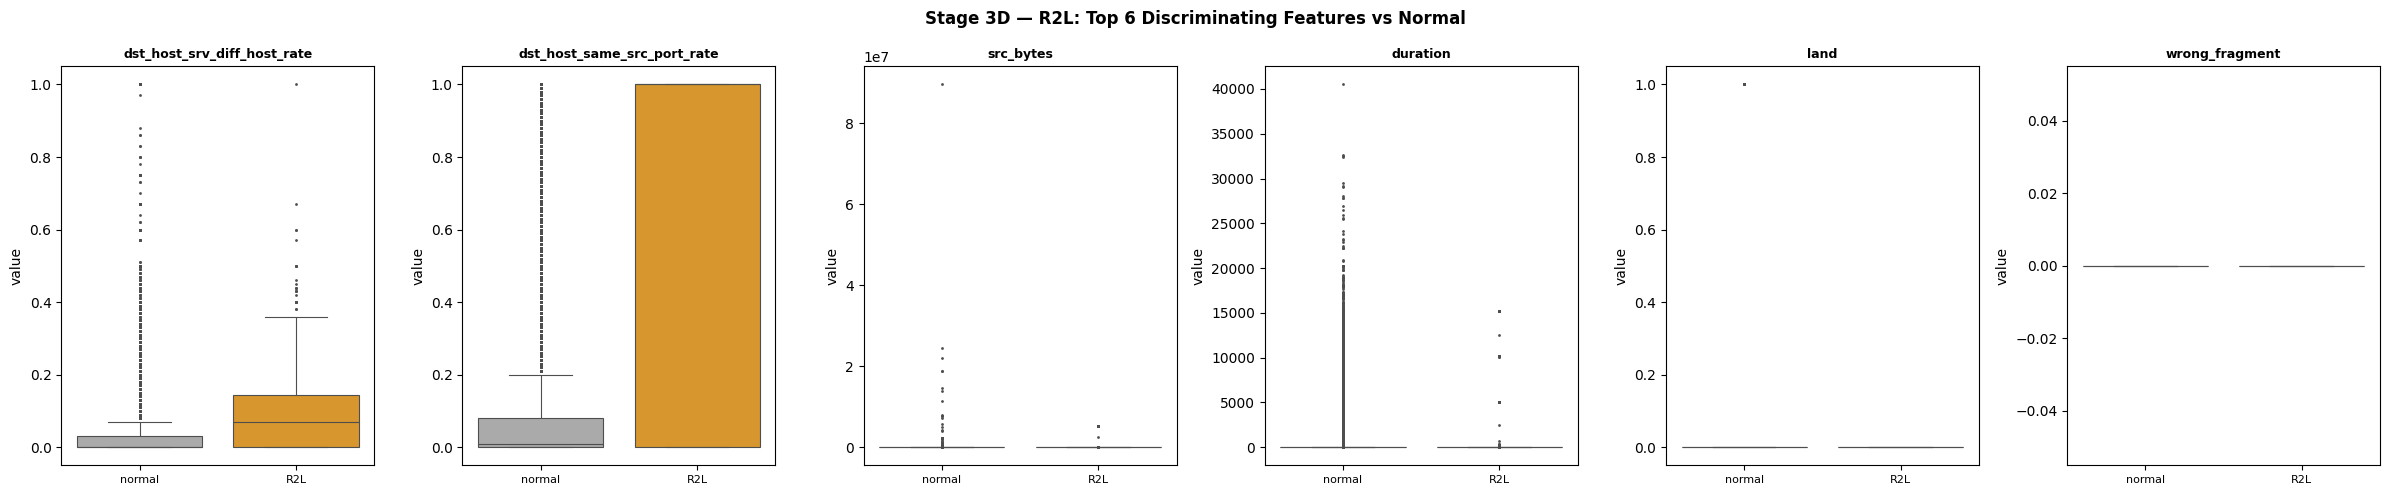

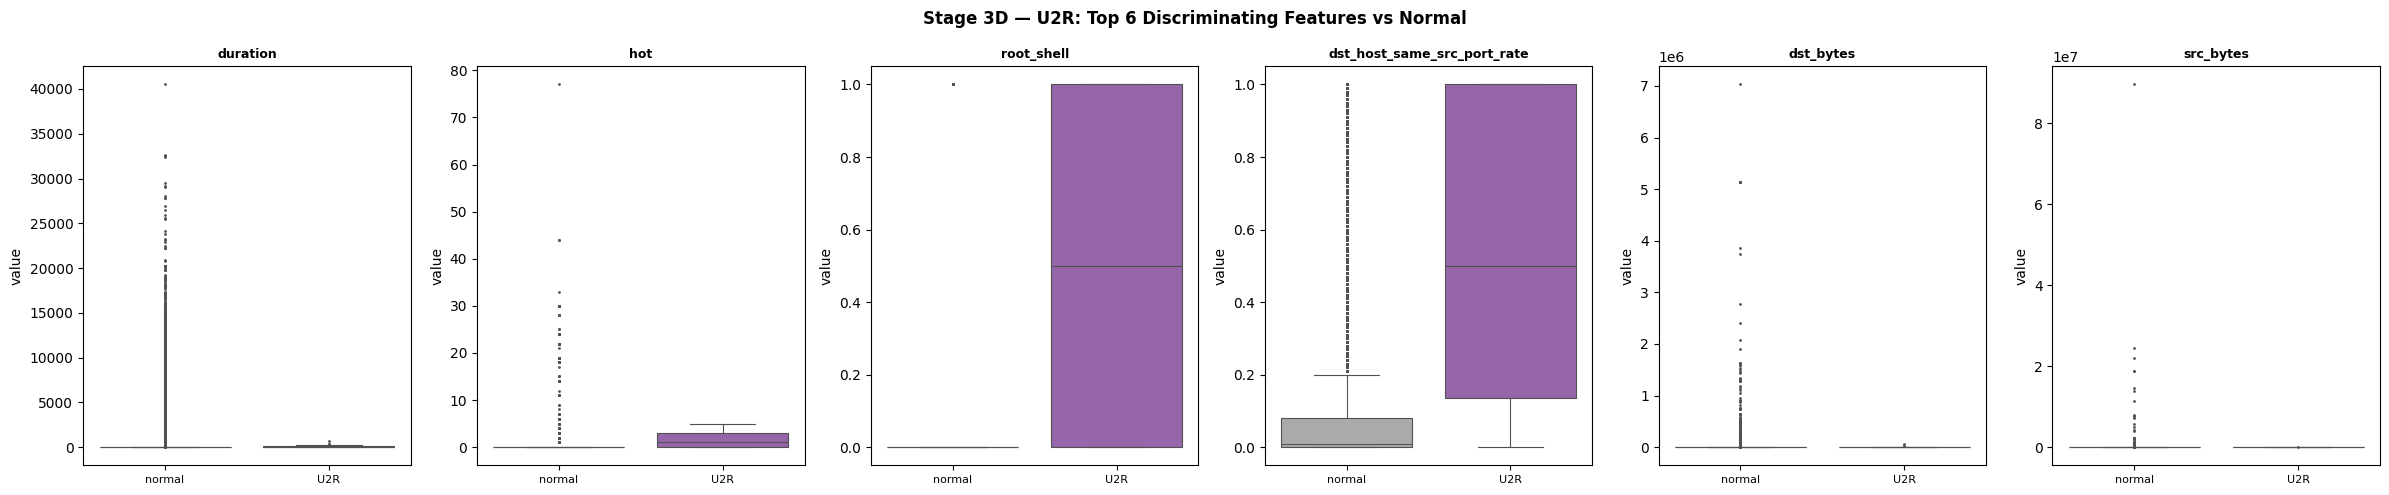

In [39]:


# Define theoretical signatures per attack category 
# These are grounded in:
# - KDD Cup 1999 dataset documentation
# - Tavallaee et al. (2009) NSL-KDD paper
# - Network security first principles

theoretical_signatures = {
    'DoS': {
        'elevated':   ['src_bytes', 'count', 'srv_count', 'serror_rate',
                       'srv_serror_rate', 'same_srv_rate'],
        'suppressed': ['dst_bytes', 'duration', 'logged_in', 'diff_srv_rate'],
        'reasoning': {
            'src_bytes':      'High-volume floods send many bytes from attacker',
            'count':          'DoS generates massive connection counts to same host',
            'serror_rate':    'SYN floods produce SYN errors (no handshake completion)',
            'same_srv_rate':  'DoS targets single service — same_srv_rate spikes to 1.0',
            'dst_bytes':      'Server overwhelmed — cannot respond, dst_bytes drops',
            'duration':       'Flooded connections are short or incomplete',
            'logged_in':      'DoS connections never authenticate'
        }
    },
    'Probe': {
        'elevated':   ['diff_srv_rate', 'dst_host_diff_srv_rate', 'rerror_rate',
                       'srv_rerror_rate', 'count', 'dst_host_count'],
        'suppressed': ['same_srv_rate', 'src_bytes', 'dst_bytes', 'logged_in'],
        'reasoning': {
            'diff_srv_rate':  'Port scanners hit many different services',
            'rerror_rate':    'Closed ports return RST — rerror spikes',
            'dst_host_count': 'Network scans touch many destination hosts',
            'same_srv_rate':  'Inverse of diff_srv_rate — scanning means variety',
            'src_bytes':      'Probe packets are small — just headers, no payload',
            'logged_in':      'Scanners do not authenticate'
        }
    },
    'R2L': {
        'elevated':   ['duration', 'num_failed_logins', 'logged_in',
                       'is_guest_login', 'hot', 'num_access_files'],
        'suppressed': ['count', 'serror_rate', 'src_bytes'],
        'reasoning': {
            'duration':          'R2L attacks persist — brute force takes time',
            'num_failed_logins': 'Credential brute force generates login failures',
            'logged_in':         'Successful R2L results in actual session',
            'is_guest_login':    'Exploiting guest accounts is common R2L vector',
            'hot':               'Successful R2L then accesses sensitive resources',
            'count':             'R2L is low-volume, targeted — not flood behavior',
            'serror_rate':       'R2L uses valid TCP handshakes, no SYN errors'
        }
    },
    'U2R': {
        'elevated':   ['root_shell', 'su_attempted', 'num_root',
                       'num_compromised', 'hot', 'num_file_creations',
                       'num_shells', 'num_access_files'],
        'suppressed': ['count', 'serror_rate', 'rerror_rate'],
        'reasoning': {
            'root_shell':        'U2R goal is root shell — this feature fires directly',
            'su_attempted':      'Privilege escalation via su is the U2R mechanism',
            'num_root':          'Root-level operations increase after escalation',
            'num_compromised':   'System compromise events accumulate post-escalation',
            'hot':               'Root access → sensitive file/dir accesses increase',
            'num_file_creations':'Attacker creates tools/backdoors post-compromise',
            'count':             'U2R is single-session, targeted — not flood'
        }
    }
}

# ── 3. Compute actual medians per category vs normal
numeric_features=train_df.select_dtypes(include=[np.number]).columns.tolist()
normal_medians=df_analysis[df_analysis['attack_category'] == 'normal'][numeric_features].median()

results={}

for cat in ['DoS', 'Probe', 'R2L', 'U2R']:
    cat_data=df_analysis[df_analysis['attack_category'] == cat][numeric_features]
    cat_medians=cat_data.median()
    # Ratio: >1 means elevated vs normal, <1 means suppressed
    ratio=(cat_medians + 1e-9)/(normal_medians + 1e-9) #1e-9 for numerical stability
    results[cat]=ratio

ratio_df=pd.DataFrame(results)

# ── 4. Print domain annotation table ─────────────────────────────────────────
print("<--- Domain Based Feature Annotation",f"{"-"*35}>")
print("   Ratio = attack_median / normal_median  |  >1 = elevated, <1 = suppressed")

for cat in ['DoS', 'Probe', 'R2L', 'U2R']:
    sig=theoretical_signatures[cat]
    print(f"\n{'─'*50}")
    print(f"  ATTACK CATEGORY: {cat}")
    print(f"{'─'*50}")
    print(f"  {'Feature':<35} {'Predicted':<12} {'Actual Ratio':<14} {'Confirmed?'}")
    print(f"  {'─'*35} {'─'*12} {'─'*14} {'─'*10}")

    all_features=sig['elevated'] + sig['suppressed']
    for feat in all_features:
        if feat not in ratio_df.index:
            continue
            
        predicted='ELEVATED' if feat in sig['elevated'] else 'SUPPRESSED'
        actual_ratio=ratio_df.loc[feat, cat]
        
        if predicted == 'ELEVATED':
            confirmed='!!' if actual_ratio > 1.2 else 'X CONTRADICTS'
        else:
            confirmed = '!!' if actual_ratio < 0.8 else 'X CONTRADICTS'
            
        reasoning=sig['reasoning'].get(feat, '')
        
        print(f"  {feat:<35} {predicted:<12} {actual_ratio:<14.3f} {confirmed}")
        
        if reasoning:
            print(f"    -> {reasoning}")

# ── 5. Heatmap of ratio matrix — all features × all attack categories ──────────
# High ratio (red) = feature elevated in that attack vs normal
# Low ratio (blue) = feature suppressed in that attack vs normal
# We log-scale the ratio for visual clarity given the extreme range.

log_ratio_df=np.log1p(ratio_df).T  # shape: (4 categories × N features)

fig, ax = plt.subplots(figsize=(28, 5))

sns.heatmap(
    log_ratio_df,
    cmap='RdBu_r',
    center=0,
    annot=False,
    linewidths=0.3,
    ax=ax,
    cbar_kws={'label': 'log(attack_median / normal_median)'}
)

ax.set_title(
    'Stage 3D : Feature Elevation/Suppression by Attack Category\n'
    'Red = elevated vs normal | Blue = suppressed vs normal',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Feature', fontsize=11)
ax.set_ylabel('Attack Category', fontsize=11)
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.savefig('../outputs/stage3d_domain_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()

# Per-category boxplots for highest-signal features 
# For each attack category, plot the top 6 most discriminating features
# (highest absolute log ratio) as boxplots against normal.
# This validates that the median-level differences are real distributions,
# not artifacts of outliers.

for cat in ['DoS', 'Probe', 'R2L', 'U2R']:
    top_features = ratio_df[cat].apply(lambda x: abs(np.log1p(x))
                                       ).nlargest(6).index.tolist()

    cat_data = df_analysis[df_analysis['attack_category'].isin([cat, 'normal'])]
    plot_data = cat_data[top_features + ['attack_category']].melt(
        id_vars='attack_category', var_name='feature', value_name='value'
    )

    fig, axes = plt.subplots(1, 6, figsize=(24, 5))
    for ax, feat in zip(axes, top_features):
        subset = plot_data[plot_data['feature'] == feat]
        sns.boxplot(
            data=subset, x='attack_category', y='value',
            palette={'normal': '#AAAAAA', cat: palette.get(cat, '#E74C3C')},
            ax=ax, fliersize=1, linewidth=0.8
        )
        ax.set_title(feat, fontsize=9, fontweight='bold')
        ax.set_xlabel('')
        ax.tick_params(axis='x', labelsize=8)

    fig.suptitle(
        f'Stage 3D — {cat}: Top 6 Discriminating Features vs Normal',
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig(f'../outputs/stage3d_boxplot_{cat.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

In [1]:
print("""
STAGE 3D FINDINGS - UMAP Visualization
══════════════════════════════════════════════════════

""")


STAGE 3D FINDINGS - UMAP Visualization
══════════════════════════════════════════════════════




# Exporatory Data Analysis - Full Summary
